# Predicting food demand at KU Mensa

## Data Collection and Preprocessing

This section describes the process of collecting, cleaning, and merging raw Excel files from the KU Mensa system.

We worked with two different data sources:
- **Produktionsplanung** (production planning): contains planned dishes, target portions, and dish descriptions for each day.
- **Verkaufszahlen** (sales data): contains the actual number of portions sold each day, divided into individually sold items and daily menus labeled as Essen 1, 2, etc.

Important:
- The Excel files had inconsistent formats, missing columns, and irregular positioning of cells.
- Dishes in the sales data were listed as "Essen", requiring cross-referencing with production planning to retrieve full descriptions.



In [129]:
import pandas as pd
import glob
import re

In [130]:
path = 'data/'

In [131]:
prod_files = glob.glob(f"{path}/*Produktionsplanung.xlsx")
prod_dfs = []

In [132]:
for file in prod_files:
    df = pd.read_excel(file)
    
    # leave only the necessary columns (the names are in German and in all files are the same)
    df_reduced = df[['Prod.Dat.', 'Gebinde', 'Bezeichnung', 'Sollmenge', 'Ausgabe']]
    
    # remame for convenience
    df_reduced.columns = ['date', 'gebinde', 'dish_name', 'target_amount', 'output']
    
    # adding it to the dataframelist
    prod_dfs.append(df_reduced)

In [133]:
prod_df = pd.concat(prod_dfs, ignore_index=True)

In [134]:
prod_df.head(10)

,date,gebinde,dish_name,target_amount,output
0,2014-01-07,Reis,Butterreis,15,15
1,2014-01-07,Kartoffeln,"Kartoffeln, geschält",3,3
2,2014-01-07,Kartoffelsalat,Kartoffelsalat fertig,80,80
3,2014-01-07,Nudeln,Nudeln Fusilli,0,0
4,2014-01-07,Spätzle,"Spätzle, frisch",0,0
5,2014-01-07,Essen 1 Mensen VK,Hacklett - Hacksteak,162,162
6,2014-01-07,Essen 2 Mensen VK,Puten Cordon Bleu mit Zitrone,240,240
7,2014-01-07,Essen 3 Mensen VK,Pasta mit Tomate-Gemüsesoße,190,190
8,2014-01-07,Pommes frites,Pommes-Frites,200,200
9,2014-01-08,Reis,Butterreis,10,10


In [135]:
prod_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16254 entries, 0 to 16253
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   date           16254 non-null  datetime64[ns]
 1   gebinde        15810 non-null  object        
 2   dish_name      16254 non-null  object        
 3   target_amount  16254 non-null  int64         
 4   output         16254 non-null  int64         
dtypes: datetime64[ns](1), int64(2), object(2)
memory usage: 635.1+ KB


In [ ]:
prod_df['date'] = pd.to_datetime(prod_df['date'], format='%d/%m/%Y')#formate date

In [140]:
# Sollmenge = 0
print(f"Total rows in all Produktionsplanung: {len(prod_df)}")

total_target_zero = (prod_df['target_amount'] == 0).sum()
print(f"Total rows in prod_df with target_amount=0: {total_target_zero}")

print(f'The proportion of such lines: {total_target_zero / len(prod_df):.2%}')

Total rows in all Produktionsplanung: 16254
Total rows in prod_df with target_amount=0: 2930
The proportion of such lines: 18.03%


In [ ]:
verkaufs_files = glob.glob('data/*Verkaufszahlen.xlsx')

verkaufs_dfs = []

for file in verkaufs_files:
    df = pd.read_excel(file, header=None)

    #  1. Read dates 

    date_row = df.loc[3, 8:]  

    # Take only non-empty dates
    valid_date_cols = date_row[date_row.notna()]
    
    # Convert to dictionary: {column: date}
    date_map = valid_date_cols.to_dict()

    #  2. Read dish names 

    row_idx = 5 
    while row_idx < len(df):
        dish = df.loc[row_idx, 6] 
        if pd.isna(dish):  
            row_idx += 1
            continue  
        #  3. Read sales for each date 
        for col_idx, raw_date in date_map.items():
            sold = df.loc[row_idx, col_idx]
            if pd.notna(sold):
                verkaufs_dfs.append({
                    'dish_name': dish,
                    'date': pd.to_datetime(raw_date, format='%Y.%m.%d', errors='coerce'),
                    'sold_amount': sold
                })
        row_idx += 1  

verkauf_df = pd.DataFrame(verkaufs_dfs)

# Filter out invalid dates (for example, if there was "Gesamt" somewhere)
verkauf_df = verkauf_df[verkauf_df['date'].notna()]
verkauf_df = verkauf_df.sort_values('date').reset_index(drop=True)

print(verkauf_df.head())


                         dish_name       date  sold_amount
0                   Kartoffelsalat 2014-01-07           74
1                             Reis 2014-01-07           15
2                       Kartoffeln 2014-01-07            3
3  Essen- Soziales ohne Berechnung 2014-01-07            1
4                    Pommes frites 2014-01-07          187


In [ ]:
verkauf_df.info()#null-values removed


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13114 entries, 0 to 13113
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   dish_name    13114 non-null  object        
 1   date         13114 non-null  datetime64[ns]
 2   sold_amount  13114 non-null  int64         
dtypes: datetime64[ns](1), int64(1), object(1)
memory usage: 307.5+ KB


In [ ]:
verkauf_df[verkauf_df['date'] == pd.Timestamp('2015-02-12')]#two examples

,dish_name,date,sold_amount
1877,Essen 5,2015-02-12,72
1878,Essen 1,2015-02-12,82
1879,Reis,2015-02-12,5
1880,Kartoffelkloss 200g,2015-02-12,8
1881,Pommes frites,2015-02-12,19
1882,Essen- Soziales ohne Berechnung,2015-02-12,1
1883,Nudeln,2015-02-12,8
1884,Essen 4,2015-02-12,33


In [144]:
prod_df[prod_df['date'] == pd.Timestamp('2015-02-12')]

,date,gebinde,dish_name,target_amount,output
2195,2015-02-12,Reis,Butterreis,15,15
2196,2015-02-12,Kloß 200 gr,"Kloß, 200g",8,8
2197,2015-02-12,Nudeln,Nudeln Spirelli,20,20
2198,2015-02-12,NaN,Kräuterbraten v.Schwein m. Kloß u. Rotk,191,191
2199,2015-02-12,Essen 4 Mensen VK,Kartoffel-Broccoli-Flan,40,40
2200,2015-02-12,Essen 5 Mensen VK,Thai- Wraps mit Chilli-Ingwer-Dip- Vegan,76,76
2201,2015-02-12,Pommes frites,Pommes-Frites,19,19


### Preliminary observations

We have collected data from two different sources:

- `prod_df`: contains information from all *Produktionsplanung* (production planning) Excel files, including planned and actual quantities (`Sollmenge`, `Ausgabe`).
- `verkauf_df`: contains sales data extracted from *Verkaufszahlen* files, representing the actual number of dishes sold per day.

Although the `Ausgabe` column in `prod_df` is meant to reflect the actual number of dishes distributed, it **does not always match** the corresponding sales values found in `verkauf_df`. This discrepancy is likely due to differences in data collection or reporting logic between the two sources.

**Conclusion:**  
For the remainder of the analysis, we will **rely on the data from `verkauf_df`** as the ground truth for the number of dishes sold, since it provides a more accurate and consistent daily breakdown of sales.

In [145]:
verkauf_df[verkauf_df['date'] == pd.Timestamp('2020-06-16')]

,dish_name,date,sold_amount
9542,Essen 4,2020-06-16,55
9543,Pizza veget./vegan,2020-06-16,7
9544,Essen 1,2020-06-16,37
9545,Pizza Fleisch/Fisch,2020-06-16,9


In [146]:
prod_df[prod_df['date'] == pd.Timestamp('2020-06-16')]

,date,gebinde,dish_name,target_amount,output
10785,2020-06-16,Essen 1 Mensen VK,Bratwürste - Fränkische Art,37,37
10786,2020-06-16,Essen 4 Mensen VK,Pasta mit Tomaten-Chilipesto und frische,0,55
10787,2020-06-16,Pizza Fleisch/Fisch,EP - Pizza Speziale,25,9
10788,2020-06-16,Kartoffeln,"Kartoffeln, gar",0,0
10789,2020-06-16,Reis,Reis,5,0
10790,2020-06-16,Pizza vegetarisch/vegan,EP - Pizza Margherita,36,7


In [147]:
# Function to extract "Essen X" from a string
def extract_essen(gebinde):
    if isinstance(gebinde, str):
        match = re.match(r'(Essen\s\d)', gebinde)
        if match:
            return match.group(1)  # return only "Essen 1"
    return gebinde  # if not Essen — return as is

# Apply to prod_df
prod_df['gebinde_clean'] = prod_df['gebinde'].apply(extract_essen)

In [148]:
prod_df.head(10)

,date,gebinde,dish_name,target_amount,output,gebinde_clean
0,2014-01-07,Reis,Butterreis,15,15,Reis
1,2014-01-07,Kartoffeln,"Kartoffeln, geschält",3,3,Kartoffeln
2,2014-01-07,Kartoffelsalat,Kartoffelsalat fertig,80,80,Kartoffelsalat
3,2014-01-07,Nudeln,Nudeln Fusilli,0,0,Nudeln
4,2014-01-07,Spätzle,"Spätzle, frisch",0,0,Spätzle
5,2014-01-07,Essen 1 Mensen VK,Hacklett - Hacksteak,162,162,Essen 1
6,2014-01-07,Essen 2 Mensen VK,Puten Cordon Bleu mit Zitrone,240,240,Essen 2
7,2014-01-07,Essen 3 Mensen VK,Pasta mit Tomate-Gemüsesoße,190,190,Essen 3
8,2014-01-07,Pommes frites,Pommes-Frites,200,200,Pommes frites
9,2014-01-08,Reis,Butterreis,10,10,Reis


In [149]:
# Merge by date and "Essen"
verkauf_df_enriched = verkauf_df.merge(
    prod_df[['date', 'gebinde_clean', 'dish_name', 'target_amount']],
    left_on=['date', 'dish_name'],
    right_on=['date', 'gebinde_clean'],
    how='left'
)

# Create the final column: use the real dish name if found, otherwise keep the original
verkauf_df_enriched['final_dish_name'] = verkauf_df_enriched['dish_name_y'].combine_first(verkauf_df_enriched['dish_name_x'])

# Remove unnecessary columns
verkauf_df_enriched = verkauf_df_enriched[['date', 'dish_name_x', 'target_amount', 'sold_amount', 'final_dish_name']]
verkauf_df_enriched.columns = ['date', 'original_name', 'target_amount', 'sold_amount', 'dish_name']


In [150]:
verkauf_df_enriched.head()

,date,original_name,target_amount,sold_amount,dish_name
0,2014-01-07,Kartoffelsalat,80.0,74,Kartoffelsalat fertig
1,2014-01-07,Reis,15.0,15,Butterreis
2,2014-01-07,Kartoffeln,3.0,3,"Kartoffeln, geschält"
3,2014-01-07,Essen- Soziales ohne Berechnung,NaN,1,Essen- Soziales ohne Berechnung
4,2014-01-07,Pommes frites,200.0,187,Pommes-Frites


In [151]:
verkauf_df_enriched.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13132 entries, 0 to 13131
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   date           13132 non-null  datetime64[ns]
 1   original_name  13132 non-null  object        
 2   target_amount  11759 non-null  float64       
 3   sold_amount    13132 non-null  int64         
 4   dish_name      13132 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(1), object(2)
memory usage: 513.1+ KB


WRONG!!!! In some cases, the 'target_amount' (i.e., the planned number of portions) is missing 
because the dish was not listed in the production planning files.
However, since we have the actual 'sold_amount' from the sales data,
we use it as a fallback estimate for the missing target.
This allows the model to have a reasonable value instead of NaN 
and prevents loss of useful training data.


In [ ]:

verkauf_df_enriched['target_amount'] = verkauf_df_enriched['target_amount'].fillna(verkauf_df_enriched['sold_amount'])#filling-in the NaNs

In [153]:
verkauf_df_enriched.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13132 entries, 0 to 13131
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   date           13132 non-null  datetime64[ns]
 1   original_name  13132 non-null  object        
 2   target_amount  13132 non-null  float64       
 3   sold_amount    13132 non-null  int64         
 4   dish_name      13132 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(1), object(2)
memory usage: 513.1+ KB


In [154]:
verkauf_df_enriched.head(10)

,date,original_name,target_amount,sold_amount,dish_name
0,2014-01-07,Kartoffelsalat,80.0,74,Kartoffelsalat fertig
1,2014-01-07,Reis,15.0,15,Butterreis
2,2014-01-07,Kartoffeln,3.0,3,"Kartoffeln, geschält"
3,2014-01-07,Essen- Soziales ohne Berechnung,1.0,1,Essen- Soziales ohne Berechnung
4,2014-01-07,Pommes frites,200.0,187,Pommes-Frites
5,2014-01-07,Essen 3,190.0,185,Pasta mit Tomate-Gemüsesoße
6,2014-01-07,Essen 2,240.0,237,Puten Cordon Bleu mit Zitrone
7,2014-01-07,Essen 1,162.0,159,Hacklett - Hacksteak
8,2014-01-08,Röstkartoffeln,34.0,34,Röstkartoffeln (EH)
9,2014-01-08,Nudeln,1.0,1,Nudeln Fusilli


## Visualization

### 1. The most popular dishes
The goal: to find out which dishes were sold most often

⚠️ Note: This visualization is not fully accurate . 
Some dishes appear multiple times with different names. It was fixed later.



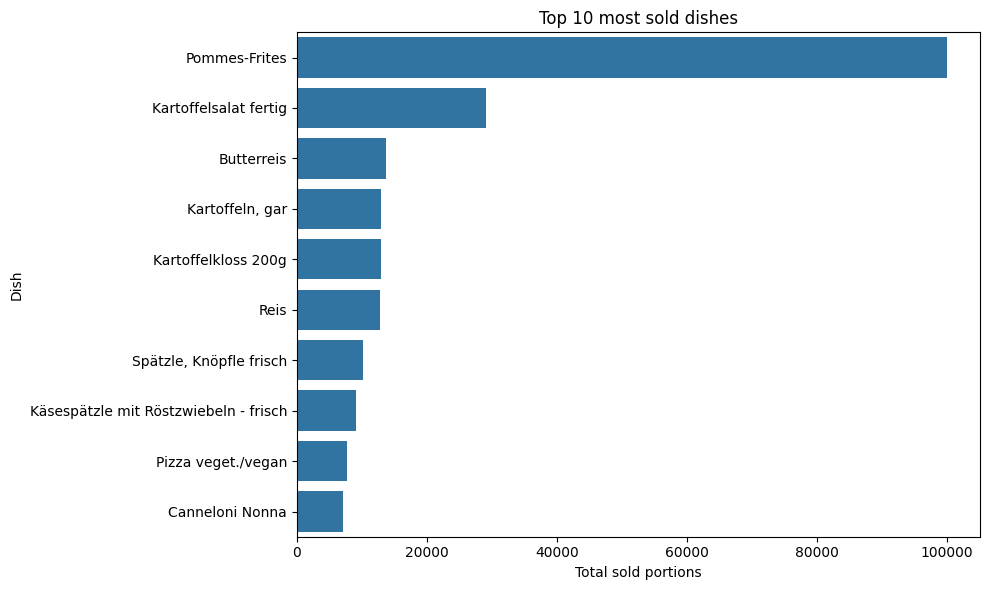

In [155]:
import matplotlib.pyplot as plt
import seaborn as sns

top_dishes = verkauf_df_enriched.groupby('dish_name')['sold_amount'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_dishes.values, y=top_dishes.index)
plt.title('Top 10 most sold dishes')
plt.xlabel('Total sold portions')
plt.ylabel('Dish')
plt.tight_layout()
plt.show()

### 2. Sales by day of the week
Goal: to understand which days of the week have the most sales

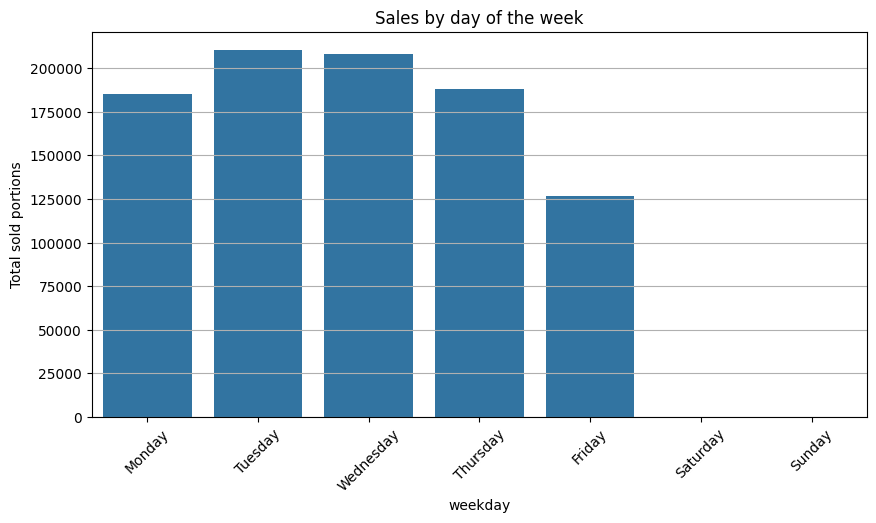

In [156]:
verkauf_df_enriched['weekday'] = pd.to_datetime(verkauf_df_enriched['date']).dt.day_name()

weekday_sales = verkauf_df_enriched.groupby('weekday')['sold_amount'].sum().reindex([
    'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'
])

plt.figure(figsize=(10, 5))
sns.barplot(x=weekday_sales.index, y=weekday_sales.values)
plt.title('Sales by day of the week')
plt.ylabel('Total sold portions')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.show()


### 3. Sales by day of the week (per year)

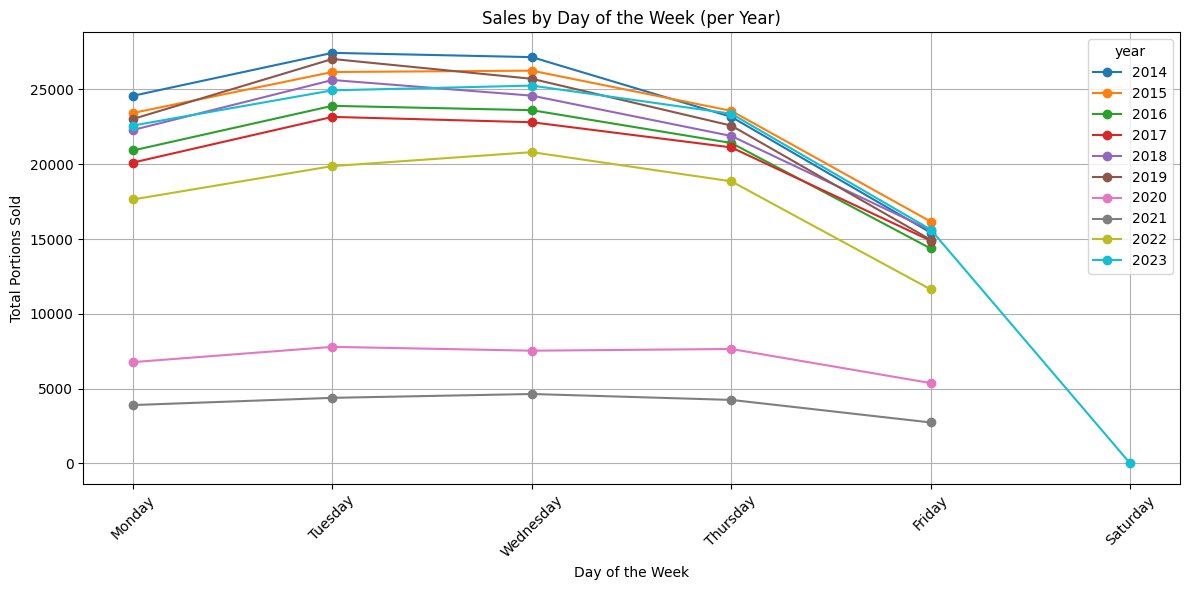

In [157]:
verkauf_df_enriched['year'] = verkauf_df_enriched['date'].dt.year
verkauf_df_enriched['weekday'] = verkauf_df_enriched['date'].dt.day_name()

grouped = (
    verkauf_df_enriched
    .groupby(['year', 'weekday'])['sold_amount']
    .sum()
    .reset_index()
)

weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
grouped['weekday'] = pd.Categorical(grouped['weekday'], categories=weekday_order, ordered=True)
grouped = grouped.sort_values(['year', 'weekday'])

pivot = grouped.pivot(index='weekday', columns='year', values='sold_amount')
pivot = pivot.reindex(weekday_order) 

pivot.plot(kind='line', marker='o', figsize=(12, 6))
plt.title('Sales by Day of the Week (per Year)')
plt.xlabel('Day of the Week')
plt.ylabel('Total Portions Sold')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 4. Comparison of Essen vs. Single Dishes
Goal: Compare total sales of Essen menus and individually sold dishes.
This helps to understand how the demand for different meal types varies by year or day of the week.

In [158]:
def categorize_dish(name):
    if isinstance(name, str) and name.strip().startswith('Essen'):
        return 'Essen (Menu)'
    else:
        return 'Single dish'

verkauf_df_enriched['dish_type'] = verkauf_df_enriched['original_name'].apply(categorize_dish)

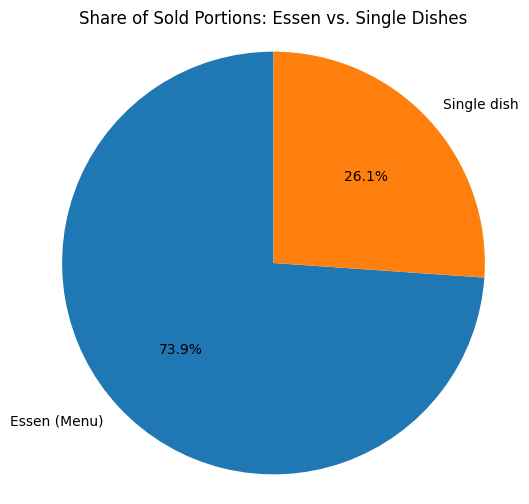

In [159]:

type_summary = verkauf_df_enriched.groupby('dish_type')['sold_amount'].sum()

plt.figure(figsize=(6, 6))
plt.pie(type_summary, labels=type_summary.index, autopct='%1.1f%%', startangle=90)
plt.title('Share of Sold Portions: Essen vs. Single Dishes')
plt.axis('equal') 
plt.show()


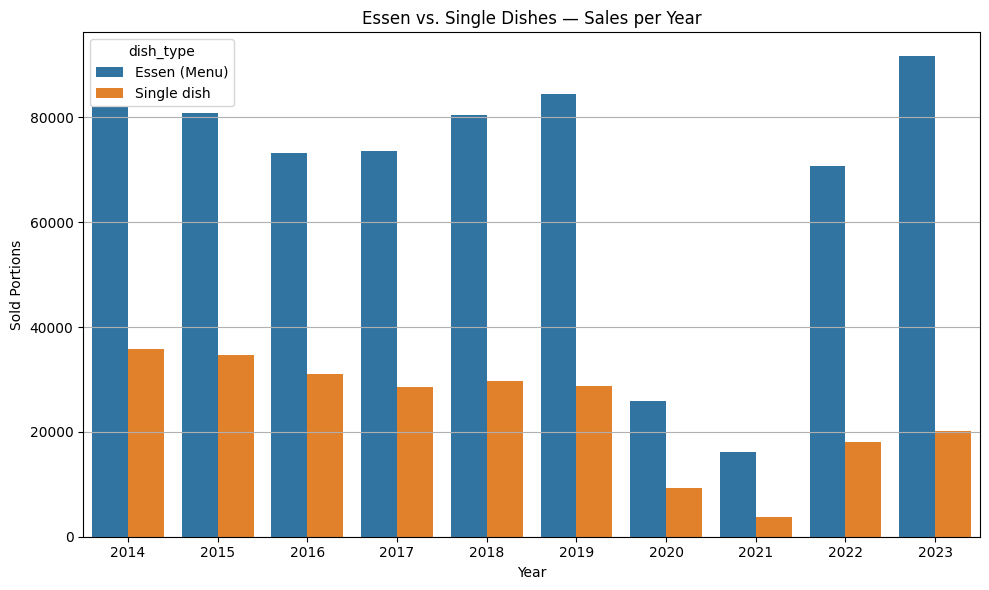

In [160]:
verkauf_df_enriched['year'] = verkauf_df_enriched['date'].dt.year
grouped_by_year = verkauf_df_enriched.groupby(['year', 'dish_type'])['sold_amount'].sum().reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(data=grouped_by_year, x='year', y='sold_amount', hue='dish_type')
plt.title('Essen vs. Single Dishes — Sales per Year')
plt.ylabel('Sold Portions')
plt.xlabel('Year')
plt.grid(axis='y')
plt.tight_layout()
plt.show()

The next analysis is based on 2018 data only.

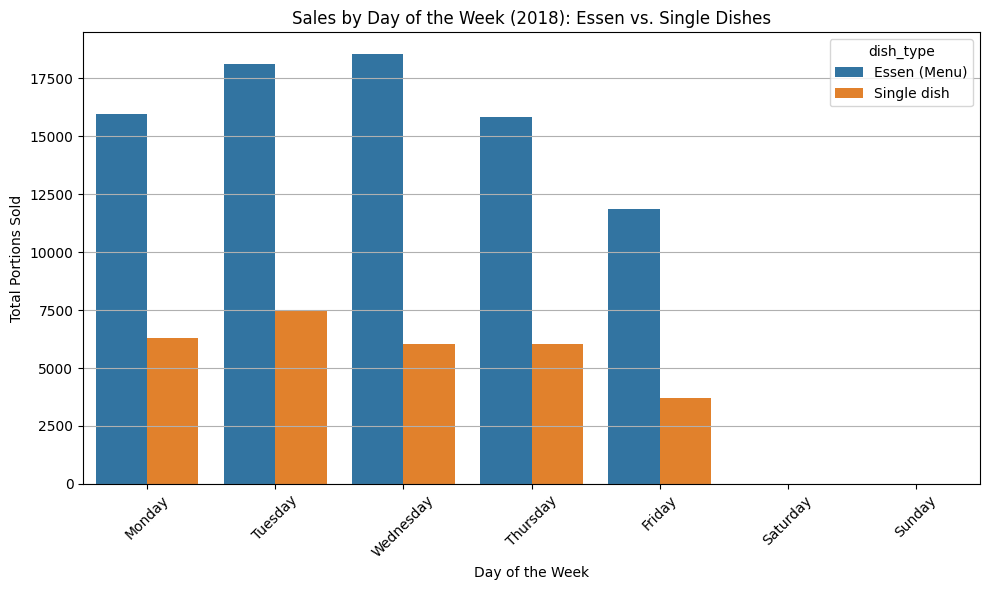

In [161]:
verkauf_df_enriched['year'] = verkauf_df_enriched['date'].dt.year
verkauf_df_enriched['weekday'] = verkauf_df_enriched['date'].dt.day_name()

df_2018 = verkauf_df_enriched[verkauf_df_enriched['year'] == 2018]

weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
grouped = (
    df_2018
    .groupby(['dish_type', 'weekday'])['sold_amount']
    .sum()
    .reset_index()
)
grouped['weekday'] = pd.Categorical(grouped['weekday'], categories=weekday_order, ordered=True)
grouped = grouped.sort_values(['weekday', 'dish_type'])

plt.figure(figsize=(10, 6))
sns.barplot(data=grouped, x='weekday', y='sold_amount', hue='dish_type')
plt.title('Sales by Day of the Week (2018): Essen vs. Single Dishes')
plt.xlabel('Day of the Week')
plt.ylabel('Total Portions Sold')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

### 5. Some more visualisations
Goal: to get a better understanding of data (is it "seasoned", what about sales in COVID-Period, lecture-free periods etc.)

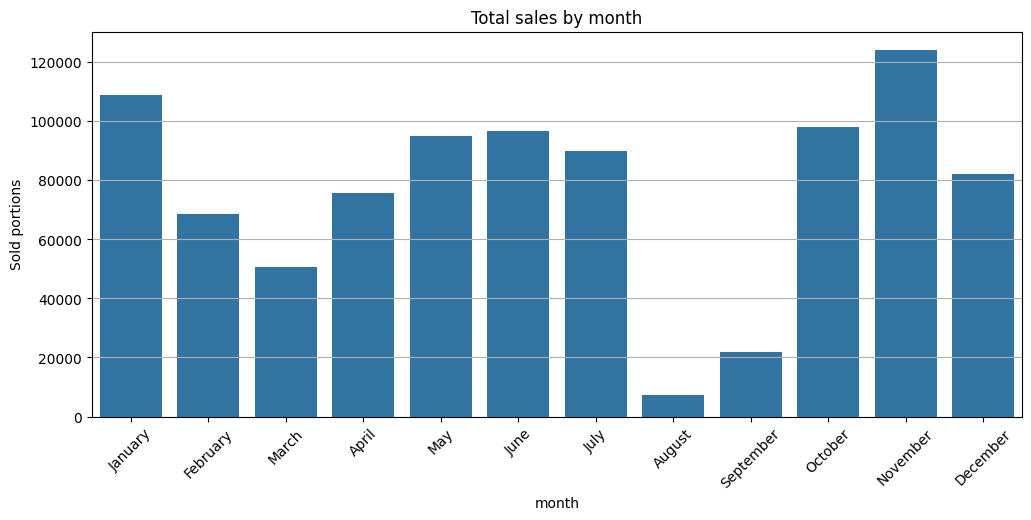

In [162]:
verkauf_df_enriched['month'] = pd.to_datetime(verkauf_df_enriched['date']).dt.month_name()

monthly_sales = verkauf_df_enriched.groupby('month')['sold_amount'].sum().reindex([
    'January', 'February', 'March', 'April', 'May', 'June',
    'July', 'August', 'September', 'October', 'November', 'December'
])

plt.figure(figsize=(12, 5))
sns.barplot(x=monthly_sales.index, y=monthly_sales.values)
plt.title('Total sales by month')
plt.ylabel('Sold portions')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.show()

How popular is a dish overall

⚠️ Note: This visualization is not fully accurate . 
Some dishes appear multiple times with different names. It was fixed later by grouping similar dishes together.

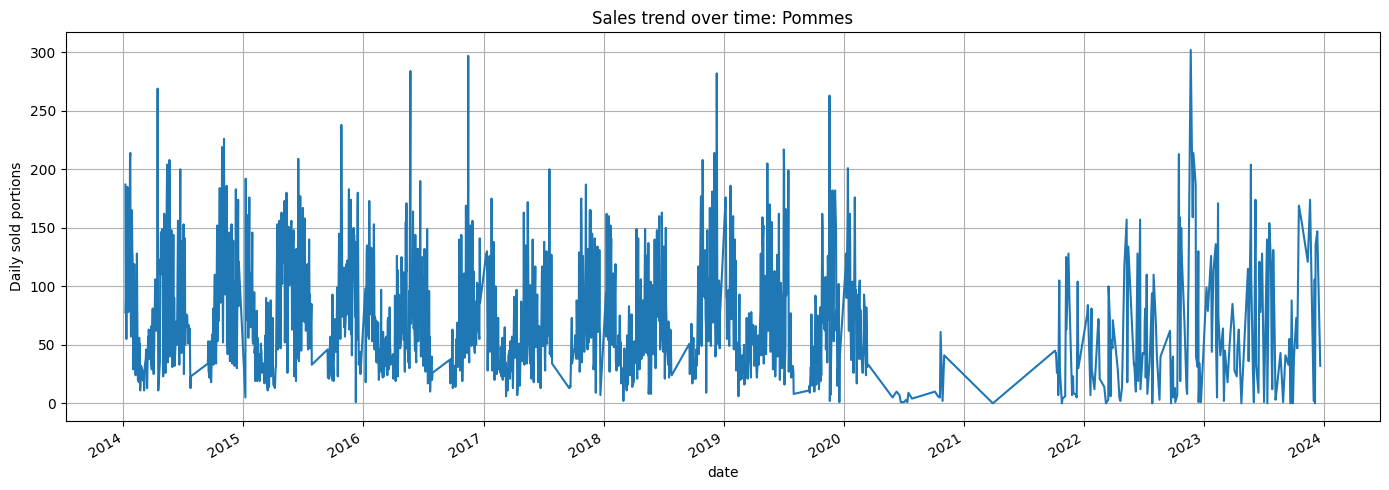

In [163]:
dish_name = 'Pommes'
df = verkauf_df_enriched[verkauf_df_enriched['dish_name'].str.contains(dish_name, case=False, na=False)]

daily_sales = df.groupby('date')['sold_amount'].sum()

plt.figure(figsize=(14, 5))
daily_sales.plot()
plt.title(f'Sales trend over time: {dish_name}')
plt.ylabel('Daily sold portions')
plt.grid()
plt.tight_layout()
plt.show()

Top 5 popular dishes plotted

⚠️ Note: This visualization is not fully accurate . 
Some dishes appear multiple times with different names. It was fixed later by grouping similar dishes.

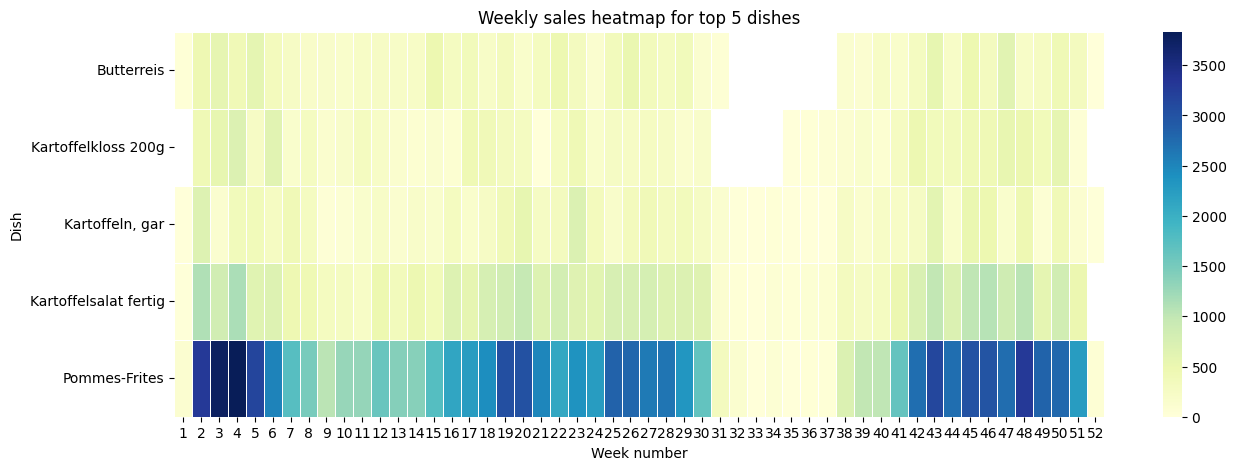

In [164]:
verkauf_df_enriched['week'] = verkauf_df_enriched['date'].dt.isocalendar().week

# Top 5 popular dishes plotted
top5_dishes = verkauf_df_enriched.groupby('dish_name')['sold_amount'].sum().sort_values(ascending=False).head(5).index

heatmap_data = verkauf_df_enriched[verkauf_df_enriched['dish_name'].isin(top5_dishes)]
heatmap_pivot = heatmap_data.pivot_table(index='dish_name', columns='week', values='sold_amount', aggfunc='sum')

plt.figure(figsize=(15, 5))
sns.heatmap(heatmap_pivot, cmap='YlGnBu', linewidths=0.5)
plt.title('Weekly sales heatmap for top 5 dishes')
plt.xlabel('Week number')
plt.ylabel('Dish')
plt.show()

## Feature Engineering

In [165]:
verkauf_df_enriched['date'] = pd.to_datetime(verkauf_df_enriched['date'])

#Time features
verkauf_df_enriched['year'] = verkauf_df_enriched['date'].dt.year
verkauf_df_enriched['month'] = verkauf_df_enriched['date'].dt.month#1–12
verkauf_df_enriched['day'] = verkauf_df_enriched['date'].dt.day#1–31
verkauf_df_enriched['weekday'] = verkauf_df_enriched['date'].dt.weekday  # 0 = monday
verkauf_df_enriched['is_weekend'] = verkauf_df_enriched['weekday'].isin([5, 6]).astype(int)#1-weekend, 0-no
verkauf_df_enriched['weekofyear'] = verkauf_df_enriched['date'].dt.isocalendar().week#week in year number
verkauf_df_enriched[['date', 'year', 'month', 'day', 'weekday', 'is_weekend', 'weekofyear']].head()

,date,year,month,day,weekday,is_weekend,weekofyear
0,2014-01-07,2014,1,7,1,0,2
1,2014-01-07,2014,1,7,1,0,2
2,2014-01-07,2014,1,7,1,0,2
3,2014-01-07,2014,1,7,1,0,2
4,2014-01-07,2014,1,7,1,0,2


In [ ]:

weekly = verkauf_df_enriched.groupby(['year', 'weekofyear'])['is_off'].sum().reset_index()
weekly.rename(columns={'is_off': 'off_days_per_week'}, inplace=True)


verkauf_df_enriched['month'] = verkauf_df_enriched['date'].dt.month
monthly = verkauf_df_enriched.groupby(['year','month'])['is_off'].sum().reset_index()
monthly.rename(columns={'is_off':'off_days_per_month'}, inplace=True)


yearly = verkauf_df_enriched.groupby('year')['is_off'].sum().reset_index()
yearly.rename(columns={'is_off':'off_days_per_year'}, inplace=True)

verkauf_df_enriched = verkauf_df_enriched.merge(weekly, on=['year','weekofyear'], how='left')
verkauf_df_enriched = verkauf_df_enriched.merge(monthly, on=['year','month'], how='left')
verkauf_df_enriched = verkauf_df_enriched.merge(yearly, on='year', how='left')

In [170]:
print("off_days_per_week value counts:\n", verkauf_df_enriched['off_days_per_week'].value_counts())
print("off_days_per_month value counts:\n", verkauf_df_enriched['off_days_per_month'].value_counts())
print("off_days_per_year value counts:\n", verkauf_df_enriched['off_days_per_year'].value_counts())

off_days_per_week value counts:
 off_days_per_week
0    13101
1       31
Name: count, dtype: int64
off_days_per_month value counts:
 off_days_per_month
0    12994
1      138
Name: count, dtype: int64
off_days_per_year value counts:
 off_days_per_year
0    11455
1     1677
Name: count, dtype: int64


### FIX! Rolling Features

To capture temporal trends and short-term seasonality in dish sales, we created **rolling average** and **rolling median** features.

For each dish, we computed:

- **7-day rolling mean and median** of `sold_amount` and `target_amount`
- **30-day rolling mean and median** of `sold_amount` and `target_amount`

These features summarize the recent sales and planning history (excluding the current day via `.shift(1)`), allowing the model to learn from past behavior.

This approach helps improve predictions, especially for frequently repeated dishes.


- Week (short trend)

In [ ]:


# sold_amount- mean for 7 days, if no histiry/mew dish-NaN
verkauf_df_enriched['rolling_7d_sold_mean'] = (
    verkauf_df_enriched.groupby('original_name')['sold_amount']
    .transform(lambda x: x.shift(1).rolling(window=7, min_periods=1).mean())
)

# 7 day median sales
verkauf_df_enriched['rolling_7d_sold_median'] = (
    verkauf_df_enriched.groupby('dish_name')['sold_amount']
    .transform(lambda x: x.shift(1).rolling(window=7, min_periods=1).median())
)
# 7 day mean target
verkauf_df_enriched['rolling_7d_target_mean'] = (
    verkauf_df_enriched.groupby('original_name')['target_amount']
    .transform(lambda x: x.shift(1).rolling(window=7, min_periods=1).mean())
)
# 7 day median target
verkauf_df_enriched['rolling_7d_target_median'] = (
    verkauf_df_enriched.groupby('dish_name')['target_amount']
    .transform(lambda x: x.shift(1).rolling(window=7, min_periods=1).median())
)
verkauf_df_enriched[['date', 'original_name', 'sold_amount', 'rolling_7d_sold_mean','rolling_7d_sold_median','rolling_7d_target_mean','rolling_7d_target_median']].tail(20)

,date,original_name,sold_amount,rolling_7d_sold_mean,rolling_7d_sold_median,rolling_7d_target_mean,rolling_7d_target_median
13112,2023-12-18,Essen 4,208,201.571429,226.0,185.714286,231.0
13113,2023-12-18,Essen 1,70,146.142857,95.0,145.714286,120.0
13114,2023-12-18,Reis,5,4.285714,3.0,4.285714,3.0
13115,2023-12-18,Essen freier Preis,1,5.857143,6.0,5.857143,6.0
13116,2023-12-19,Reis,4,4.857143,4.0,4.857143,4.0
13117,2023-12-19,Essen freier Preis,33,5.000000,5.0,5.000000,5.0
13118,2023-12-19,Essen 5,252,186.000000,301.0,223.142857,180.0
13119,2023-12-19,Essen 4,89,204.571429,59.5,181.428571,60.5
13120,2023-12-19,Essen 1,164,140.714286,NaN,140.000000,NaN
13121,2023-12-20,Essen freier Preis,3,8.000000,5.0,8.000000,5.0


It is better to replace dish_name and original_name with one single normalized feature when the LLM is ready.

- Month (long trend)

In [173]:
# 30 days mean  (no info-Nan)
verkauf_df_enriched['rolling_30d_sold_mean'] = (
    verkauf_df_enriched.groupby('dish_name')['sold_amount']
    .transform(lambda x: x.shift(1).rolling(window=30, min_periods=1).mean())
)


# 30 days median (no info-Nan)
verkauf_df_enriched['rolling_30d_sold_median'] = (
    verkauf_df_enriched.groupby('dish_name')['sold_amount']
    .transform(lambda x: x.shift(1).rolling(window=30, min_periods=1).median())
)
# 30 days mean  (no info-Nan)
verkauf_df_enriched['rolling_30d_target_mean'] = (
    verkauf_df_enriched.groupby('dish_name')['target_amount']
    .transform(lambda x: x.shift(1).rolling(window=30, min_periods=1).mean())
)


# 30 days median (no info-Nan)
verkauf_df_enriched['rolling_30d_target_median'] = (
    verkauf_df_enriched.groupby('dish_name')['target_amount']
    .transform(lambda x: x.shift(1).rolling(window=30, min_periods=1).median())
)
verkauf_df_enriched[['date', 'original_name', 'sold_amount', 'rolling_30d_sold_mean','rolling_30d_sold_median','rolling_30d_target_mean','rolling_30d_target_median']].tail()

,date,original_name,sold_amount,rolling_30d_sold_mean,rolling_30d_sold_median,rolling_30d_target_mean,rolling_30d_target_median
13127,2023-12-21,Essen 4,167,132.000000,132.0,133.000000,133.0
13128,2023-12-21,Pommes frites,32,61.600000,43.0,57.900000,42.5
13129,2023-12-21,Kartoffelsalat,4,32.866667,21.5,37.900000,22.0
13130,2023-12-21,Essen 1,115,116.545455,86.0,119.818182,90.0
13131,2023-12-22,Essen freier Preis,13,6.900000,4.5,6.900000,4.5


In [174]:
verkauf_df_enriched.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13132 entries, 0 to 13131
Data columns (total 26 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   date                       13132 non-null  datetime64[ns]
 1   original_name              13132 non-null  object        
 2   target_amount              13132 non-null  float64       
 3   sold_amount                13132 non-null  int64         
 4   dish_name                  13132 non-null  object        
 5   weekday                    13132 non-null  int32         
 6   year                       13132 non-null  int32         
 7   dish_type                  13132 non-null  object        
 8   month                      13132 non-null  int32         
 9   week                       13132 non-null  UInt32        
 10  day                        13132 non-null  int32         
 11  is_weekend                 13132 non-null  int64         
 12  week

In [ ]:
#adding daily total sales column
daily_sales = verkauf_df_enriched.groupby('date')['sold_amount'].sum().rename('daily_total_sales')

verkauf_df_enriched = verkauf_df_enriched.merge(daily_sales, on='date')

verkauf_df_enriched['rolling_7d_total_sales'] = (
    verkauf_df_enriched['daily_total_sales'].shift(1).rolling(window=7, min_periods=1).mean()
)

verkauf_df_enriched[['date', 'sold_amount', 'daily_total_sales', 'rolling_7d_total_sales']].tail(10)


,date,sold_amount,daily_total_sales,rolling_7d_total_sales
13122,2023-12-20,106,505,530.428571
13123,2023-12-20,2,505,531.428571
13124,2023-12-20,69,505,526.142857
13125,2023-12-20,325,505,520.857143
13126,2023-12-21,8,326,515.571429
13127,2023-12-21,167,326,484.714286
13128,2023-12-21,32,326,453.857143
13129,2023-12-21,4,326,428.285714
13130,2023-12-21,115,326,402.714286
13131,2023-12-22,13,13,377.142857


In [176]:
verkauf_df_enriched['rolling_30d_total_sales'] = (
    verkauf_df_enriched['daily_total_sales'].shift(1).rolling(window=30, min_periods=1).mean()
)

verkauf_df_enriched[['date', 'sold_amount', 'daily_total_sales', 'rolling_7d_total_sales', 'rolling_30d_total_sales']].tail(10)


,date,sold_amount,daily_total_sales,rolling_7d_total_sales,rolling_30d_total_sales
13122,2023-12-20,106,505,530.428571,604.333333
13123,2023-12-20,2,505,531.428571,590.833333
13124,2023-12-20,69,505,526.142857,577.333333
13125,2023-12-20,325,505,520.857143,573.533333
13126,2023-12-21,8,326,515.571429,569.733333
13127,2023-12-21,167,326,484.714286,559.966667
13128,2023-12-21,32,326,453.857143,550.200000
13129,2023-12-21,4,326,428.285714,534.300000
13130,2023-12-21,115,326,402.714286,518.400000
13131,2023-12-22,13,13,377.142857,502.500000


In [177]:
verkauf_df_enriched.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13132 entries, 0 to 13131
Data columns (total 29 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   date                       13132 non-null  datetime64[ns]
 1   original_name              13132 non-null  object        
 2   target_amount              13132 non-null  float64       
 3   sold_amount                13132 non-null  int64         
 4   dish_name                  13132 non-null  object        
 5   weekday                    13132 non-null  int32         
 6   year                       13132 non-null  int32         
 7   dish_type                  13132 non-null  object        
 8   month                      13132 non-null  int32         
 9   week                       13132 non-null  UInt32        
 10  day                        13132 non-null  int32         
 11  is_weekend                 13132 non-null  int64         
 12  week

### Handling Missing Values in Rolling Features

The rolling statistics (mean/median over 7 and 30 days) contain missing values at the beginning of each dish's sales history, because there is not enough past data for the rolling window.

To avoid losing useful rows during modeling, we fill these missing values with the mean of each corresponding column. This provides a reasonable estimate and allows the model to still benefit from the rolling features, especially when history is short.


In [178]:
rolling_cols = [col for col in verkauf_df_enriched.columns if 'rolling_' in col]
verkauf_df_enriched[rolling_cols] = verkauf_df_enriched[rolling_cols].fillna(verkauf_df_enriched[rolling_cols].mean())


In [179]:
verkauf_df_enriched.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13132 entries, 0 to 13131
Data columns (total 29 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   date                       13132 non-null  datetime64[ns]
 1   original_name              13132 non-null  object        
 2   target_amount              13132 non-null  float64       
 3   sold_amount                13132 non-null  int64         
 4   dish_name                  13132 non-null  object        
 5   weekday                    13132 non-null  int32         
 6   year                       13132 non-null  int32         
 7   dish_type                  13132 non-null  object        
 8   month                      13132 non-null  int32         
 9   week                       13132 non-null  UInt32        
 10  day                        13132 non-null  int32         
 11  is_weekend                 13132 non-null  int64         
 12  week

Dish frequency:

In [180]:
dish_freq = verkauf_df_enriched['original_name'].value_counts()
verkauf_df_enriched['dish_freq'] = verkauf_df_enriched['original_name'].map(dish_freq)


Essen or Single:

In [181]:
verkauf_df_enriched['is_essen'] = (verkauf_df_enriched['dish_type'] == 'Essen (Menu)').astype(int)


In [182]:
verkauf_df_enriched.head(10)

,date,original_name,target_amount,sold_amount,dish_name,weekday,year,dish_type,month,week,...,rolling_7d_target_median,rolling_30d_sold_mean,rolling_30d_sold_median,rolling_30d_target_mean,rolling_30d_target_median,daily_total_sales,rolling_7d_total_sales,rolling_30d_total_sales,dish_freq,is_essen
0,2014-01-07,Kartoffelsalat,80.0,74,Kartoffelsalat fertig,1,2014,Single dish,1,2,...,66.616574,66.668705,62.374719,69.736775,65.690484,861,510.153182,510.445974,945,0
1,2014-01-07,Reis,15.0,15,Butterreis,1,2014,Single dish,1,2,...,66.616574,66.668705,62.374719,69.736775,65.690484,861,861.000000,861.000000,1506,0
2,2014-01-07,Kartoffeln,3.0,3,"Kartoffeln, geschält",1,2014,Single dish,1,2,...,66.616574,66.668705,62.374719,69.736775,65.690484,861,861.000000,861.000000,625,0
3,2014-01-07,Essen- Soziales ohne Berechnung,1.0,1,Essen- Soziales ohne Berechnung,1,2014,Essen (Menu),1,2,...,66.616574,66.668705,62.374719,69.736775,65.690484,861,861.000000,861.000000,192,1
4,2014-01-07,Pommes frites,200.0,187,Pommes-Frites,1,2014,Single dish,1,2,...,66.616574,66.668705,62.374719,69.736775,65.690484,861,861.000000,861.000000,1417,0
5,2014-01-07,Essen 3,190.0,185,Pasta mit Tomate-Gemüsesoße,1,2014,Essen (Menu),1,2,...,66.616574,66.668705,62.374719,69.736775,65.690484,861,861.000000,861.000000,419,1
6,2014-01-07,Essen 2,240.0,237,Puten Cordon Bleu mit Zitrone,1,2014,Essen (Menu),1,2,...,66.616574,66.668705,62.374719,69.736775,65.690484,861,861.000000,861.000000,1304,1
7,2014-01-07,Essen 1,162.0,159,Hacklett - Hacksteak,1,2014,Essen (Menu),1,2,...,66.616574,66.668705,62.374719,69.736775,65.690484,861,861.000000,861.000000,1812,1
8,2014-01-08,Röstkartoffeln,34.0,34,Röstkartoffeln (EH),2,2014,Single dish,1,2,...,66.616574,66.668705,62.374719,69.736775,65.690484,676,861.000000,861.000000,140,0
9,2014-01-08,Nudeln,1.0,1,Nudeln Fusilli,2,2014,Single dish,1,2,...,66.616574,66.668705,62.374719,69.736775,65.690484,676,834.571429,840.444444,511,0


In [183]:
verkauf_df_enriched.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13132 entries, 0 to 13131
Data columns (total 31 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   date                       13132 non-null  datetime64[ns]
 1   original_name              13132 non-null  object        
 2   target_amount              13132 non-null  float64       
 3   sold_amount                13132 non-null  int64         
 4   dish_name                  13132 non-null  object        
 5   weekday                    13132 non-null  int32         
 6   year                       13132 non-null  int32         
 7   dish_type                  13132 non-null  object        
 8   month                      13132 non-null  int32         
 9   week                       13132 non-null  UInt32        
 10  day                        13132 non-null  int32         
 11  is_weekend                 13132 non-null  int64         
 12  week

## Model

### Target Variable

Our goal is to predict the number of sold portions for each dish on a given day.  
Thus, we define **`sold_amount`** as the target variable for our regression task.

This target is continuous and numerical, making this a classic **regression problem**.


In [184]:
y = verkauf_df_enriched['sold_amount']

features = [
    'year', 'month', 'day', 'weekday', 'is_weekend', 'weekofyear',
    'rolling_7d_sold_mean', 'rolling_7d_sold_median',    
    'rolling_30d_sold_mean', 'rolling_30d_sold_median',
    'rolling_7d_total_sales', 'rolling_30d_total_sales',
    'dish_freq', 'is_essen'
]
X = verkauf_df_enriched[features]

### Train/Test Split Strategy

Since we are working with time series data, it is crucial to avoid data leakage by using a chronological split.

We sorted the dataset by date and used the **first 80%** of the observations as the training set, and the **remaining 20%** as the test set.  
This ensures that the model only sees past data when making predictions on the future, simulating a real-world forecasting scenario.


In [185]:
verkauf_df_enriched = verkauf_df_enriched.sort_values('date')

split_index = int(len(X) * 0.8)
X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]


### Random Forest

In [186]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

MAE_RF_full = mean_absolute_error(y_test, y_pred)
R2_RF_full = r2_score(y_test, y_pred)

print("Random Forest evaluation:")
print("MAE:", mean_absolute_error(y_test, y_pred))
print("R²:", r2_score(y_test, y_pred))


Random Forest evaluation:
MAE: 27.856387514274836
R²: 0.7127193176692116


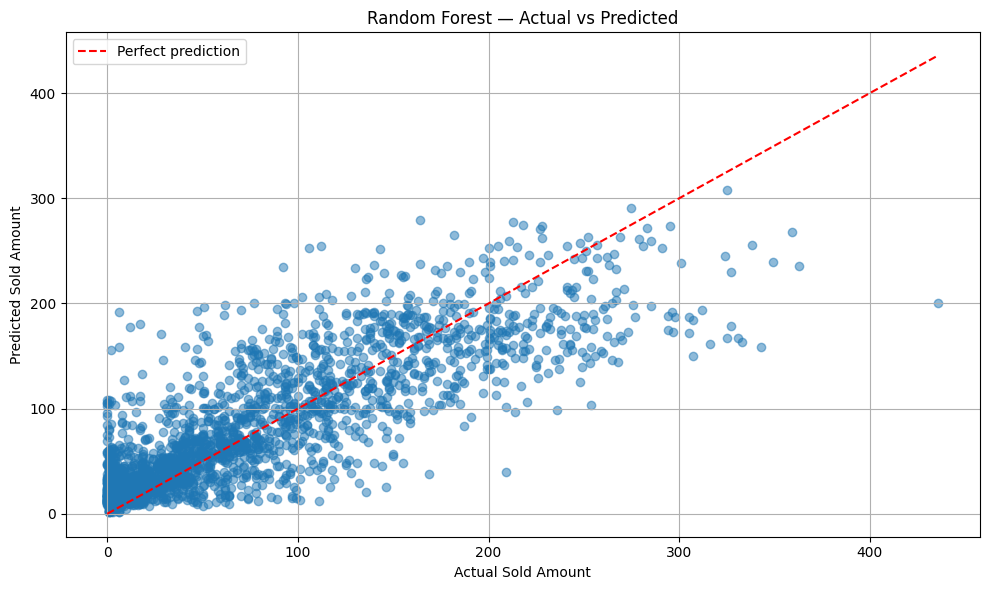

In [187]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
         color='red', linestyle='--', label='Perfect prediction')

plt.xlabel('Actual Sold Amount')
plt.ylabel('Predicted Sold Amount')
plt.title('Random Forest — Actual vs Predicted')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

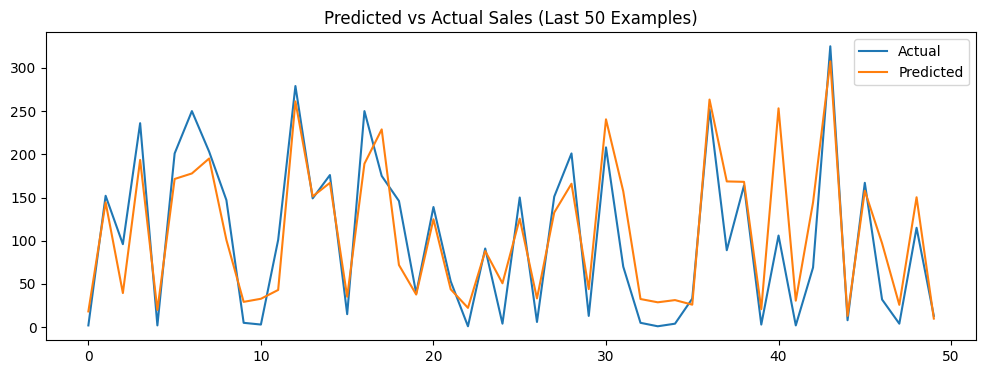

In [188]:
plt.figure(figsize=(12, 4))
plt.plot(y_test.values[-50:], label='Actual')
plt.plot(y_pred[-50:], label='Predicted')
plt.legend()
plt.title('Predicted vs Actual Sales (Last 50 Examples)')
plt.show()

### Linear Regression

In [189]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

MAE_LR_full = mean_absolute_error(y_test, y_pred_lr)
R2_LR_full = r2_score(y_test, y_pred_lr)

print("Linear Regression evaluation:")
print("Linear Regression MAE:", mean_absolute_error(y_test, y_pred_lr))
print("Linear Regression R²:", r2_score(y_test, y_pred_lr))


Linear Regression evaluation:
Linear Regression MAE: 30.227219973640267
Linear Regression R²: 0.6845980097683957


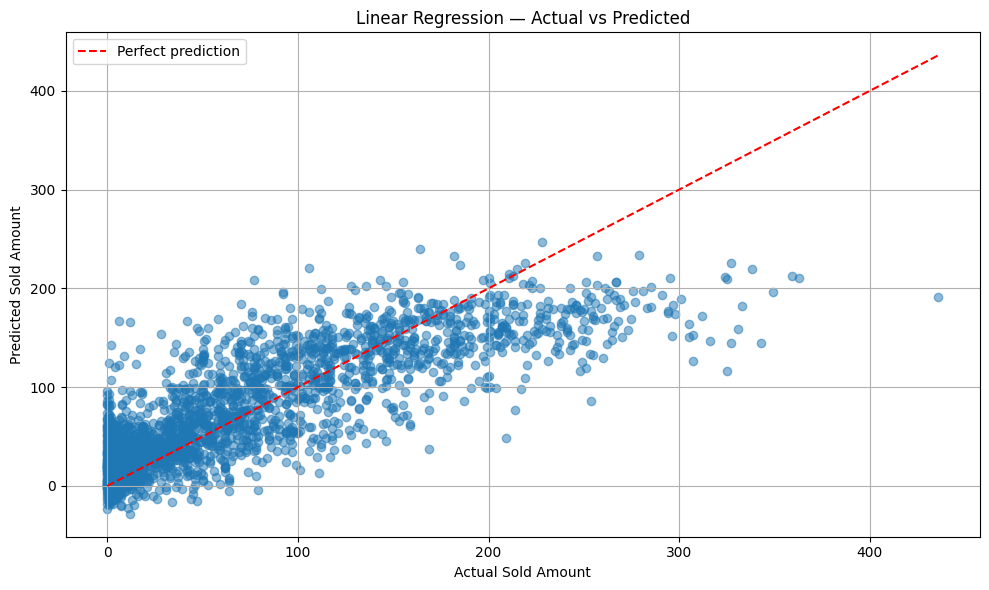

In [190]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_lr, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
         color='red', linestyle='--', label='Perfect prediction')

plt.xlabel('Actual Sold Amount')
plt.ylabel('Predicted Sold Amount')
plt.title('Linear Regression — Actual vs Predicted')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

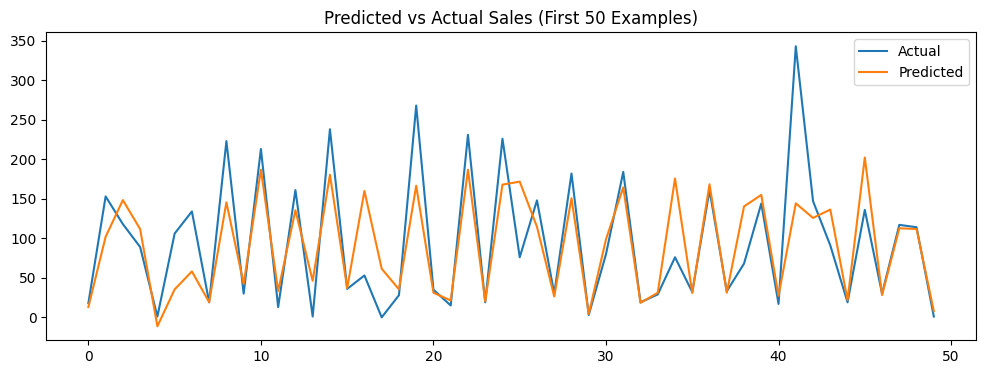

In [191]:
plt.figure(figsize=(12, 4))
plt.plot(y_test.values[:50], label='Actual')
plt.plot(y_pred_lr[:50], label='Predicted')
plt.legend()
plt.title('Predicted vs Actual Sales (First 50 Examples)')
plt.show()

## Ignore Single dishes and Covid years
We decided to try learning without COVID-Years and Single Disches, since these are clearly the outliers highly effecting the performance

In [314]:
# Exclude COVID years
df_no_covid = verkauf_df_enriched[~verkauf_df_enriched['year'].isin([2020, 2021])].copy()


In [315]:
# Essen 1–5 only
df_essen_only = verkauf_df_enriched[
    verkauf_df_enriched['original_name'].astype(str).str.contains(r"Essen\s[1-5]")
].copy()


In [316]:
df_essen_no_covid = df_essen_only[~df_essen_only['year'].isin([2020, 2021])].copy()


In [317]:
df_essen_no_covid.head()

,date,original_name,target_amount,sold_amount,dish_name,weekday,year,dish_type,month,week,...,rolling_7d_target_median,rolling_30d_sold_mean,rolling_30d_sold_median,rolling_30d_target_mean,rolling_30d_target_median,daily_total_sales,rolling_7d_total_sales,rolling_30d_total_sales,dish_freq,is_essen
5,2014-01-07,Essen 3,190.0,185,Pasta mit Tomate-Gemüsesoße,1,2014,Essen (Menu),1,2,...,66.616574,66.668705,62.374719,69.736775,65.690484,861,861.000000,861.000000,419,1
6,2014-01-07,Essen 2,240.0,237,Puten Cordon Bleu mit Zitrone,1,2014,Essen (Menu),1,2,...,66.616574,66.668705,62.374719,69.736775,65.690484,861,861.000000,861.000000,1304,1
7,2014-01-07,Essen 1,162.0,159,Hacklett - Hacksteak,1,2014,Essen (Menu),1,2,...,66.616574,66.668705,62.374719,69.736775,65.690484,861,861.000000,861.000000,1812,1
13,2014-01-08,Essen 4,60.0,52,Nudelpfanne mit Muschelfleisch und Papri,2,2014,Essen (Menu),1,2,...,66.616574,66.668705,62.374719,69.736775,65.690484,676,728.857143,789.846154,1523,1
14,2014-01-08,Essen 5,270.0,265,Rösti Hauptgericht,2,2014,Essen (Menu),1,2,...,66.616574,66.668705,62.374719,69.736775,65.690484,676,702.428571,781.714286,666,1


In [196]:
X_n = df_essen_no_covid[features]
y_n = df_essen_no_covid['sold_amount']

In [197]:
split_index = int(len(X_n) * 0.8)
X_train_n, X_test_n = X_n.iloc[:split_index], X_n.iloc[split_index:]
y_train_n, y_test_n = y_n.iloc[:split_index], y_n.iloc[split_index:]

In [198]:
#Random Forest
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train_n, y_train_n)
y_pred_n = model.predict(X_test_n)

MAE_RF_essen = mean_absolute_error(y_test_n, y_pred_n)
R2_RF_essen = r2_score(y_test_n, y_pred_n)

print("Random Forest evaluation (df_essen_no_covid):")
print("MAE:", mean_absolute_error(y_test_n, y_pred_n))
print("R²:", r2_score(y_test_n, y_pred_n))

Random Forest evaluation (df_essen_no_covid):
MAE: 35.30911320754716
R²: 0.6086201175254851


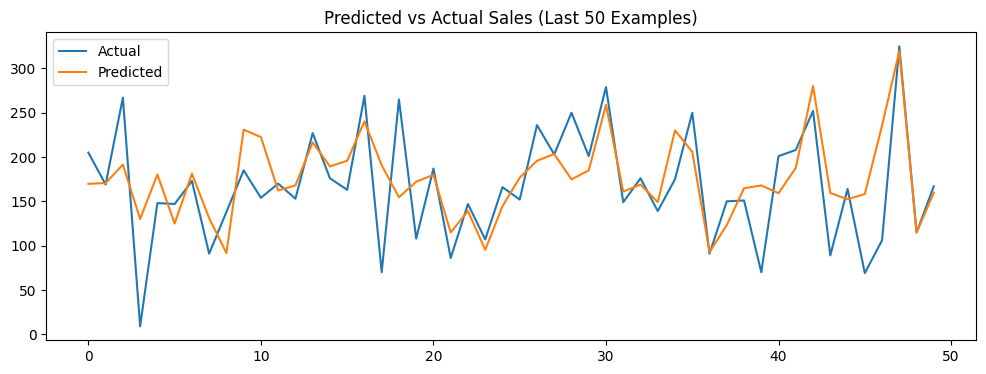

In [199]:
plt.figure(figsize=(12, 4))
plt.plot(y_test_n.values[-50:], label='Actual')
plt.plot(y_pred_n[-50:], label='Predicted')
plt.legend()
plt.title('Predicted vs Actual Sales (Last 50 Examples)')
plt.show()

In [200]:
#Linear Regression
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train_n, y_train_n)
y_pred_lr_n = lr.predict(X_test_n)

MAE_LR_essen = mean_absolute_error(y_test_n, y_pred_lr_n)
R2_LR_essen = r2_score(y_test_n, y_pred_lr_n)

print("Linear Regression (df_essen_no_covid) evaluation:")
print("Linear Regression MAE:", mean_absolute_error(y_test_n, y_pred_lr_n))
print("Linear Regression R²:", r2_score(y_test_n, y_pred_lr_n))


Linear Regression (df_essen_no_covid) evaluation:
Linear Regression MAE: 36.83307103643172
Linear Regression R²: 0.5945840315432911


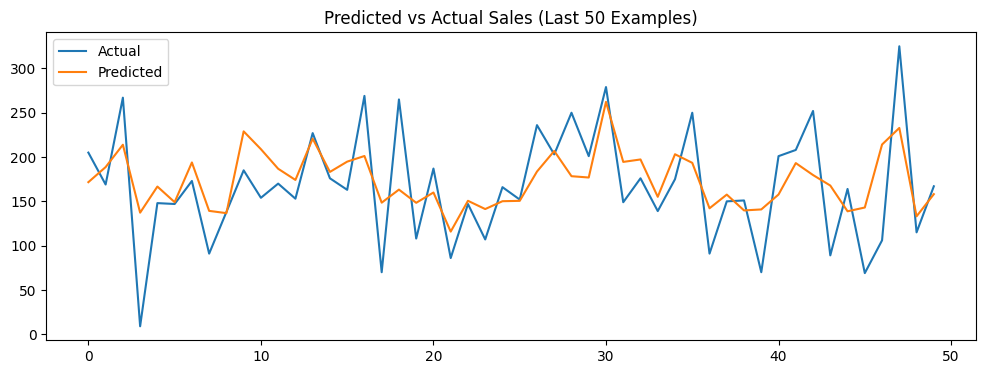

In [201]:
plt.figure(figsize=(12, 4))
plt.plot(y_test_n.values[-50:], label='Actual')
plt.plot(y_pred_lr_n[-50:], label='Predicted')
plt.legend()
plt.title('Predicted vs Actual Sales (Last 50 Examples)')
plt.show()

In [202]:
print(f"Random Forest evaluation (on full data):") 
print(f"MAE: {MAE_RF_full:.2f}")
print(f"R² Score: {R2_RF_full:.2f}\n")

print(f"Linear Regression evaluation (on full data):") 
print(f"MAE: {MAE_LR_full:.2f}")
print(f"R² Score: {R2_LR_full:.2f}\n")

print(f"Random Forest evaluation (Essen 1-5, no COVID):") 
print(f"MAE: {MAE_RF_essen:.2f}")
print(f"R² Score: {R2_RF_essen:.2f}\n")


print(f"Linear Regression evaluation (Essen 1-5, no COVID):") 
print(f"MAE: {MAE_LR_essen:.2f}")
print(f"R² Score: {R2_LR_essen:.2f}")

Random Forest evaluation (on full data):
MAE: 27.86
R² Score: 0.71

Linear Regression evaluation (on full data):
MAE: 30.23
R² Score: 0.68

Random Forest evaluation (Essen 1-5, no COVID):
MAE: 35.31
R² Score: 0.61

Linear Regression evaluation (Essen 1-5, no COVID):
MAE: 36.83
R² Score: 0.59


## Prediction of total sales per day
In this section, we train a model to predict the total number of dishes sold per day.
This allows us to estimate overall demand for the Mensa on a daily level.
Such predictions can help with overall staff planning and kitchen logistics.

In [203]:
daily_df = verkauf_df_enriched.groupby('date').agg({
    'sold_amount': 'sum',
    'weekday': 'first',
    'is_weekend': 'first',
    'month': 'first',
    'year': 'first',
    'weekofyear': 'first',
    'rolling_7d_total_sales': 'first'  
}).reset_index()

daily_df.rename(columns={'sold_amount': 'total_sales'}, inplace=True)


In [204]:
daily_df = daily_df.sort_values('date')

split_index = int(len(daily_df) * 0.8)
train_df = daily_df.iloc[:split_index]
test_df = daily_df.iloc[split_index:]


In [205]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

features = ['weekday', 'month', 'is_weekend', 'weekofyear', 'rolling_7d_total_sales']
X_train = train_df[features]
y_train = train_df['total_sales']
X_test = test_df[features]
y_test = test_df['total_sales']

model = RandomForestRegressor(random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:.2f}")
print(f"R²: {r2:.2f}")


MAE: 66.62
R²: 0.84


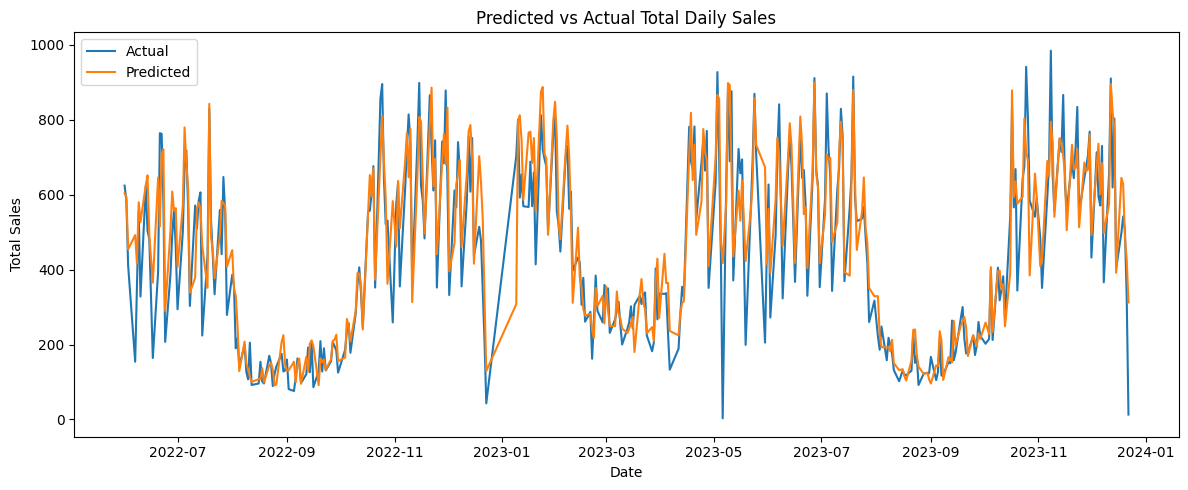

In [206]:
plt.figure(figsize=(12, 5))
plt.plot(test_df['date'], y_test, label='Actual')
plt.plot(test_df['date'], y_pred, label='Predicted')
plt.title('Predicted vs Actual Total Daily Sales')
plt.xlabel('Date')
plt.ylabel('Total Sales')
plt.legend()
plt.tight_layout()
plt.show()

In [207]:
df_essen_only.info()


<class 'pandas.core.frame.DataFrame'>
Index: 5724 entries, 5 to 13127
Data columns (total 31 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   date                       5724 non-null   datetime64[ns]
 1   original_name              5724 non-null   object        
 2   target_amount              5724 non-null   float64       
 3   sold_amount                5724 non-null   int64         
 4   dish_name                  5724 non-null   object        
 5   weekday                    5724 non-null   int32         
 6   year                       5724 non-null   int32         
 7   dish_type                  5724 non-null   object        
 8   month                      5724 non-null   int32         
 9   week                       5724 non-null   UInt32        
 10  day                        5724 non-null   int32         
 11  is_weekend                 5724 non-null   int64         
 12  weekofyear

In [208]:
df_essen_no_covid.info()


<class 'pandas.core.frame.DataFrame'>
Index: 5300 entries, 5 to 13127
Data columns (total 31 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   date                       5300 non-null   datetime64[ns]
 1   original_name              5300 non-null   object        
 2   target_amount              5300 non-null   float64       
 3   sold_amount                5300 non-null   int64         
 4   dish_name                  5300 non-null   object        
 5   weekday                    5300 non-null   int32         
 6   year                       5300 non-null   int32         
 7   dish_type                  5300 non-null   object        
 8   month                      5300 non-null   int32         
 9   week                       5300 non-null   UInt32        
 10  day                        5300 non-null   int32         
 11  is_weekend                 5300 non-null   int64         
 12  weekofyear

In [ ]:
# Save df_essen_only as a pickle file for later use in embedding.
# Pickle format preserves all DataFrame information (data, types, index, etc.) for reliable reloading.

#df_essen_only.to_pickle('data/df_essen_only.pkl')

### Analysis after embedding
(Generating step can be found in the separate file)

In [ ]:
import pickle
import pandas as pd

with open('pickle_files/dish_embeddings.pkl', 'rb') as f:
    dish_embeddings = pickle.load(f)


embedding_df = pd.DataFrame.from_dict(dish_embeddings, orient='index')
embedding_df.reset_index(inplace=True)
embedding_df.rename(columns={'index': 'dish_name'}, inplace=True)


In [ ]:
df_essen_only_llm = df_essen_only.merge(embedding_df, on='dish_name', how='left')

In [ ]:
df_essen_only_llm.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5724 entries, 0 to 5723
Columns: 799 entries, date to 767
dtypes: UInt32(2), bool(2), datetime64[ns](1), float64(779), int32(4), int64(8), object(3)
memory usage: 34.7+ MB


In [ ]:
embedding_df.head()

,dish_name,0,1,2,3,4,5,6,7,8,...,758,759,760,761,762,763,764,765,766,767
0,Pasta mit Tomate-Gemüsesoße,0.021249,-0.034028,0.005527,0.009006,0.047246,0.023477,-0.002105,-0.016127,0.035557,...,-0.004310,0.020344,-0.051341,0.032908,-0.029573,0.000782,-0.043373,0.032240,-0.020990,-0.014158
1,Puten Cordon Bleu mit Zitrone,0.017317,-0.056851,-0.070699,-0.027099,0.014342,0.008165,-0.011565,-0.006481,0.034186,...,0.022824,0.018682,-0.067907,0.023231,-0.040663,0.060269,-0.005830,0.018221,-0.056192,-0.030810
2,Hacklett - Hacksteak,0.021459,-0.000691,-0.059774,-0.066763,0.038330,-0.001738,-0.013816,-0.016254,0.062202,...,0.019436,-0.001189,-0.023183,-0.011423,0.033921,0.018404,0.020297,-0.032669,-0.039641,0.008642
3,Nudelpfanne mit Muschelfleisch und Papri,-0.036713,-0.016585,0.000595,0.018914,0.016347,0.012880,-0.001823,-0.025439,0.029771,...,0.039184,0.022784,-0.046973,0.055940,-0.021821,-0.014707,-0.011800,0.017561,-0.032900,0.037525
4,Rösti Hauptgericht,-0.008220,-0.019783,-0.044453,-0.033724,0.014393,0.045740,-0.030042,-0.046713,0.018144,...,-0.017783,0.023003,-0.033578,0.006598,-0.025619,0.045689,-0.072074,-0.000586,-0.014357,0.013391


 Visualizing  and listing the clusters 

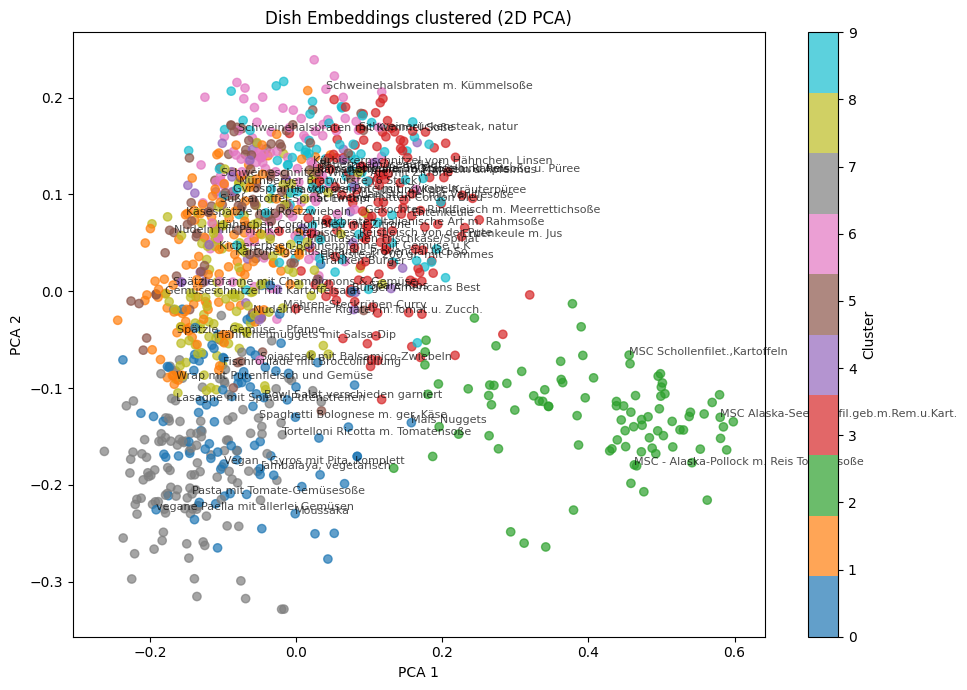

In [ ]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA


# Assume embedding_df has 'dish_name' and embedding columns (e.g., 0, 1, ..., n)
embedding_cols = [col for col in embedding_df.columns if col != 'dish_name']
X = embedding_df[embedding_cols].values

# Cluster the embeddings
n_clusters = 10
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
embedding_df['cluster'] = kmeans.fit_predict(X)

# Reduce to 2D for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.figure(figsize=(10, 7))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=embedding_df['cluster'], cmap='tab10', alpha=0.7)
plt.title('Dish Embeddings clustered (2D PCA)')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.colorbar(scatter, label='Cluster')
for i, name in enumerate(embedding_df['dish_name']):
    if i % 20 == 0:  # annotate every 20th for readability
        plt.annotate(name, (X_pca[i, 0], X_pca[i, 1]), fontsize=8, alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
for cluster_id in range(n_clusters):
    cluster_members = embedding_df[embedding_df['cluster'] == cluster_id]['dish_name'].tolist()
    print(f"Cluster {cluster_id} ({len(cluster_members)} dishes):")
    for name in cluster_members:
        print(f"  - {name}")
    print()

Cluster 0 (95 dishes):
  - Bami Goreng
  - Thai- Wraps mit Chilli-Ingwer-Dip- Vegan
  - Gemüsecurry mit Sojawürfel
  - Veggie-Nuggets
  - vegetarisches Chili / Chili sin Carne
  - Zucchini gebacken
  - Sabzi Korma ( indisch, Blumenkohl und Ge
  - Chili con Carne
  - vegetarische Paella mit allerlei Gemüsen
  - Gefüllte Paprikaschote vegetarisch
  - Wildragout mit Cranberries und Pilzen
  - Jambalaya, vegetarisch
  - Jambalaya, vegetarisch mit Reis
  - Tofugulasch - Vegan
  - Veganer Dönerteller - Komplett
  - Orietalische Bulgurpfanne - vegan
  - veganes Chili / Chili sin Carne
  - Gemüsecurry mit Sojawürfel i. Reisrand
  - Veggie-Nuggets m. Kräuter-Dip
  - Soja-Mais-Chili mit Paprikareis
  - Veg. Frühlingsrolle mit Sweet Chili Soße
  - Chili con Carne mit Cajunreis
  - Veganer Dönerteller m.Krautsalat u. Reis
  - Sesamnudeln mit Teriyaki-Wokgemüse - veg
  - Nasi Goreng
  - Moussaka
  - Pilz-Stroganoff mit Gemüse Pilaw - vegan
  - Linseneintopf vegan
  - Falafeltasche mit Salat - Vegan

In [ ]:
# Check if the word "Essen" appears anywhere in the 'dish_name' column of embedding_df
contains_essen = df_essen_only['dish_name'].str.contains('Essen', case=False, na=False).any()
count_essen = df_essen_only['dish_name'].str.contains('Essen', case=False, na=False).sum()
print("Is 'Essen' present in any dish_name?:", contains_essen)
print("How many times does 'Essen' appear in dish_name?:", count_essen)

# Print all rows where 'Essen' appears in dish_name
essen_rows = df_essen_only[df_essen_only['dish_name'].str.contains('Essen', case=False, na=False)]
print("Rows with 'Essen' in dish_name:")
print(essen_rows)

Is 'Essen' present in any dish_name?: True
How many times does 'Essen' appear in dish_name?: 105
Rows with 'Essen' in dish_name:
            date original_name  target_amount  sold_amount dish_name  weekday  \
556   2014-04-14       Essen 3            1.0            1   Essen 3        0   
715   2014-05-15       Essen 3           24.0           24   Essen 3        3   
1140  2014-09-19       Essen 1           83.0           83   Essen 1        4   
1137  2014-09-19       Essen 5           23.0           23   Essen 5        4   
1215  2014-10-06       Essen 4            1.0            1   Essen 4        0   
...          ...           ...            ...          ...       ...      ...   
12634 2023-09-13       Essen 3            1.0            1   Essen 3        2   
12641 2023-09-14       Essen 4            0.0            0   Essen 4        3   
12643 2023-09-15       Essen 1            0.0            0   Essen 1        4   
12821 2023-10-24       Essen 3            1.0            1   

In [ ]:
df_essen_no_covid[df_essen_no_covid['date'] == pd.Timestamp('2014-09-19')]

,date,original_name,target_amount,sold_amount,dish_name,weekday,year,dish_type,month,week,...,rolling_7d_target_median,rolling_30d_sold_mean,rolling_30d_sold_median,rolling_30d_target_mean,rolling_30d_target_median,daily_total_sales,rolling_7d_total_sales,rolling_30d_total_sales,dish_freq,is_essen
1139,2014-09-19,Essen 4,28.0,20,Nudeln Penne Rigate - Portion,4,2014,Essen (Menu),9,38,...,66.000000,61.071429,49.000000,65.214286,58.500000,210,215.714286,245.566667,1523,1
1138,2014-09-19,Essen 4,28.0,20,Griesbrei mit Zimt und Zucker,4,2014,Essen (Menu),9,38,...,32.500000,28.000000,28.000000,32.500000,32.500000,210,218.571429,247.300000,1523,1
1140,2014-09-19,Essen 1,83.0,83,Essen 1,4,2014,Essen (Menu),9,38,...,66.616574,66.668705,62.374719,69.736775,65.690484,210,212.857143,243.833333,1812,1
1136,2014-09-19,Essen 2,30.0,26,"Schweinerückensteak, natur",4,2014,Essen (Menu),9,38,...,119.500000,124.250000,116.000000,128.000000,119.500000,210,224.285714,250.766667,1304,1
1137,2014-09-19,Essen 5,23.0,23,Essen 5,4,2014,Essen (Menu),9,38,...,66.616574,66.668705,62.374719,69.736775,65.690484,210,221.428571,249.033333,666,1


In [ ]:

verkauf_df_enriched[verkauf_df_enriched['date'] == pd.Timestamp('2014-09-19')]

,date,original_name,target_amount,sold_amount,dish_name,weekday,year,dish_type,month,week,...,rolling_7d_target_median,rolling_30d_sold_mean,rolling_30d_sold_median,rolling_30d_target_mean,rolling_30d_target_median,daily_total_sales,rolling_7d_total_sales,rolling_30d_total_sales,dish_freq,is_essen
1142,2014-09-19,Pommes frites,22.0,22,Pommes-Frites,4,2014,Single dish,9,38,...,28.000000,70.533333,66.000000,73.333333,67.000000,210,210.000000,239.833333,1417,0
1141,2014-09-19,Kartoffeln,2.0,2,"Kartoffeln, geschält",4,2014,Single dish,9,38,...,24.000000,39.833333,18.500000,40.766667,18.500000,210,210.000000,242.100000,625,0
1139,2014-09-19,Essen 4,28.0,20,Nudeln Penne Rigate - Portion,4,2014,Essen (Menu),9,38,...,66.000000,61.071429,49.000000,65.214286,58.500000,210,215.714286,245.566667,1523,1
1138,2014-09-19,Essen 4,28.0,20,Griesbrei mit Zimt und Zucker,4,2014,Essen (Menu),9,38,...,32.500000,28.000000,28.000000,32.500000,32.500000,210,218.571429,247.300000,1523,1
1140,2014-09-19,Essen 1,83.0,83,Essen 1,4,2014,Essen (Menu),9,38,...,66.616574,66.668705,62.374719,69.736775,65.690484,210,212.857143,243.833333,1812,1
1136,2014-09-19,Essen 2,30.0,26,"Schweinerückensteak, natur",4,2014,Essen (Menu),9,38,...,119.500000,124.250000,116.000000,128.000000,119.500000,210,224.285714,250.766667,1304,1
1135,2014-09-19,Kartoffelsalat,12.0,12,Kartoffelsalat fertig,4,2014,Single dish,9,38,...,14.000000,29.733333,21.000000,31.100000,22.000000,210,227.142857,252.500000,945,0
1134,2014-09-19,Reis,2.0,2,Butterreis,4,2014,Single dish,9,38,...,9.000000,23.133333,13.500000,23.433333,13.500000,210,230.000000,254.233333,1506,0
1137,2014-09-19,Essen 5,23.0,23,Essen 5,4,2014,Essen (Menu),9,38,...,66.616574,66.668705,62.374719,69.736775,65.690484,210,221.428571,249.033333,666,1


# Analyzing PCA

In [ ]:
df_embeddings = pd.DataFrame([
    {'dish_name': name, 'embedding': emb}
    for name, emb in dish_embeddings.items()
])

In [ ]:
df_embeddings.head()

,dish_name,embedding
0,Pasta mit Tomate-Gemüsesoße,"[0.02124859, -0.03402806, 0.0055268896, 0.0090..."
1,Puten Cordon Bleu mit Zitrone,"[0.01731671, -0.056851085, -0.07069918, -0.027..."
2,Hacklett - Hacksteak,"[0.021459313, -0.00069075805, -0.05977393, -0...."
3,Nudelpfanne mit Muschelfleisch und Papri,"[-0.03671253, -0.01658475, 0.0005951046, 0.018..."
4,Rösti Hauptgericht,"[-0.008220069, -0.019782962, -0.04445282, -0.0..."


In [ ]:
from sklearn.decomposition import PCA
import numpy as np


X_embed = np.vstack(df_embeddings['embedding'].values)  # shape (n_samples, 768)

# Apply PCA to reduce dimensionality while preserving 95% variance
pca = PCA(n_components=0.95, random_state=42)
X_pca = pca.fit_transform(X_embed)

print(f"Number of components explaining 95% variance: {pca.n_components_}")

pca = PCA(n_components=0.9, random_state=42)
X_pca = pca.fit_transform(X_embed)

print(f"Number of components explaining 90% variance: {pca.n_components_}")

Number of components explaining 95% variance: 188
Number of components explaining 90% variance: 127


In [ ]:
embeddings_expanded = embedding_df.copy()

embeddings_expanded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1035 entries, 0 to 1034
Columns: 770 entries, dish_name to cluster
dtypes: float64(768), int32(1), object(1)
memory usage: 6.1+ MB


In [ ]:
pca = PCA(n_components=127, random_state=42)
X_embed = embeddings_expanded.drop(columns=['dish_name']).values
pca_result  = pca.fit_transform(X_embed)

pca_columns = [f'pca_{i+1}' for i in range(pca_result.shape[1])]
pca_df = pd.DataFrame(pca_result, columns=pca_columns)

pca_df['dish_name'] = embeddings_expanded['dish_name'].values
pca_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1035 entries, 0 to 1034
Columns: 128 entries, pca_1 to dish_name
dtypes: float64(127), object(1)
memory usage: 1.0+ MB


In [ ]:
# Merge PCA results with the original df_essen_no_covid
essen_no_covid_with_pca = df_essen_no_covid.merge(pca_df, on='dish_name', how='left')

print(essen_no_covid_with_pca.shape)
essen_no_covid_with_pca.head()

(5300, 158)


,date,original_name,target_amount,sold_amount,dish_name,weekday,year,dish_type,month,week,...,pca_118,pca_119,pca_120,pca_121,pca_122,pca_123,pca_124,pca_125,pca_126,pca_127
0,2014-01-07,Essen 3,190.0,185,Pasta mit Tomate-Gemüsesoße,1,2014,Essen (Menu),1,2,...,-0.019738,-0.003462,-0.004066,-0.004574,0.002372,0.030825,-0.035010,0.005599,-0.000357,-0.002364
1,2014-01-07,Essen 2,240.0,237,Puten Cordon Bleu mit Zitrone,1,2014,Essen (Menu),1,2,...,-0.006247,-0.018329,-0.010918,-0.010651,-0.010709,-0.005348,0.020259,0.012572,-0.007586,-0.011672
2,2014-01-07,Essen 1,162.0,159,Hacklett - Hacksteak,1,2014,Essen (Menu),1,2,...,-0.026481,0.002155,-0.022696,-0.004224,-0.009222,0.000658,-0.003810,0.017200,-0.028891,-0.012784
3,2014-01-08,Essen 4,60.0,52,Nudelpfanne mit Muschelfleisch und Papri,2,2014,Essen (Menu),1,2,...,0.021517,-0.016025,0.006354,0.030698,-0.019687,0.019709,-0.017798,0.015527,-0.017592,0.007981
4,2014-01-08,Essen 5,270.0,265,Rösti Hauptgericht,2,2014,Essen (Menu),1,2,...,-0.036721,-0.015873,-0.017668,0.005889,-0.014636,-0.005482,0.048118,-0.018609,0.009268,-0.022485


### Learning the models with our new PCA-features
Using Standard features :
    'year', 'month', 'day', 'weekday', 'is_weekend', 'weekofyear',
    'rolling_7d_sold_mean', 'rolling_7d_sold_median',    
    'rolling_30d_sold_mean', 'rolling_30d_sold_median',
    'rolling_7d_total_sales', 'rolling_30d_total_sales',
    'dish_freq', 'is_essen'

& PCA-features to predict "sold_amount"

In [ ]:
y = essen_no_covid_with_pca['sold_amount']

# Features
base_features = [
    'year', 'weekday', 'month', 'day', 'is_weekend', 'weekofyear',
     'rolling_7d_sold_mean', 'rolling_7d_sold_median',    
    'rolling_30d_sold_mean', 'rolling_30d_sold_median',
    'rolling_7d_total_sales', 'rolling_30d_total_sales'
]

pca_features = [col for col in essen_no_covid_with_pca.columns if col.startswith('pca_')]

X = essen_no_covid_with_pca[base_features + pca_features]

In [ ]:
essen_no_covid_with_pca = essen_no_covid_with_pca.sort_values('date')
split_index = int(len(essen_no_covid_with_pca) * 0.8)
X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]

In [ ]:
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

MAE_RF = mean_absolute_error(y_test, y_pred)
R2_RF = r2_score(y_test, y_pred)

print("Random Forest evaluation:")
print("MAE:", mean_absolute_error(y_test, y_pred))
print("R²:", r2_score(y_test, y_pred))

Random Forest evaluation:
MAE: 33.083245283018876
R²: 0.6435695103650809


In [ ]:
essen_no_covid_with_pca[['dish_freq'] + pca_features].corr()['dish_freq'].abs().sort_values(ascending=False)


dish_freq    1.000000
pca_43       0.144243
pca_36       0.143791
pca_34       0.142596
pca_35       0.116128
               ...   
pca_81       0.002885
pca_30       0.002385
pca_14       0.001750
pca_126      0.001066
pca_42       0.000680
Name: dish_freq, Length: 128, dtype: float64

## Below we also trained many other models in order to improve our results.

### XGBoost

In [ ]:
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, median_absolute_error, mean_squared_error, r2_score

y = essen_no_covid_with_pca['sold_amount']

X = essen_no_covid_with_pca[base_features + pca_features]

essen_no_covid_with_pca = essen_no_covid_with_pca.sort_values('date')
split_idx = int(len(essen_no_covid_with_pca) * 0.8)

X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]


In [ ]:
model_xgb = xgb.XGBRegressor(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model_xgb.fit(X_train, y_train)
y_pred_xgb = model_xgb.predict(X_test)


In [ ]:
mae = mean_absolute_error(y_test, y_pred_xgb)
r2 = r2_score(y_test, y_pred_xgb)

print(f"XGBoost MAE: {mae:.2f}")
print(f"XGBoost R²: {r2:.2f}")

XGBoost MAE: 32.34
XGBoost R²: 0.66


### Grid Search for XGBoost 
- max_depth
- learning_rate
- n_estimators

In [ ]:
from sklearn.model_selection import GridSearchCV

xgb_model = xgb.XGBRegressor(objective='reg:squarederror', random_state=42)

param_grid = {
    'max_depth': [4, 6, 8],
    'learning_rate': [0.05, 0.1, 0.2],
    'n_estimators': [100, 200]
}

# Grid Search
grid_search = GridSearchCV(estimator=xgb_model,
                           param_grid=param_grid,
                           cv=3,
                           scoring='neg_mean_absolute_error',
                           verbose=2,
                           n_jobs=-1)

grid_search.fit(X_train, y_train)

print(f"Best parameters: {grid_search.best_params_}")
print(f"Best MAE (neg): {grid_search.best_score_:.2f}")


Fitting 3 folds for each of 18 candidates, totalling 54 fits
Best parameters: {'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 200}
Best MAE (neg): -32.78


In [ ]:
y_pred_best = grid_search.best_estimator_.predict(X_test)

In [ ]:
mae = mean_absolute_error(y_test, y_pred_best)
r2 = r2_score(y_test, y_pred_best)

print(f"XGBoost MAE: {mae:.2f}")
print(f"XGBoost R²: {r2:.2f}")

XGBoost MAE: 32.54
XGBoost R²: 0.65


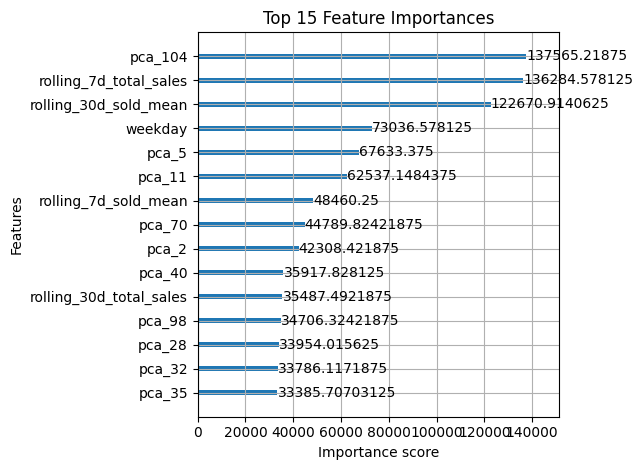

In [ ]:
#Importance of features

xgb.plot_importance(grid_search.best_estimator_, max_num_features=15, importance_type='gain')
plt.title('Top 15 Feature Importances')
plt.tight_layout()
plt.show()

In [ ]:
mae_baseline = mean_absolute_error(
    verkauf_df_enriched[verkauf_df_enriched['is_essen'] == 1]['sold_amount'],
    verkauf_df_enriched[verkauf_df_enriched['is_essen'] == 1]['target_amount']
)
print(f"Baseline MAE (Mensa plan, Not Essen only): {mae_baseline:.2f}")


Baseline MAE (Mensa plan, Not Essen only): 13.65


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans


unique_dishes = essen_no_covid_with_pca['dish_name'].dropna().unique()

vectorizer = TfidfVectorizer()
X_tfidf = vectorizer.fit_transform(unique_dishes)

n_clusters=100

kmeans = KMeans(n_clusters=n_clusters, random_state=42)
clusters = kmeans.fit_predict(X_tfidf)

dish_to_cluster = dict(zip(unique_dishes, clusters))

essen_nc_pca_cluster = essen_no_covid_with_pca.copy()
essen_nc_pca_cluster['dish_cluster'] = essen_nc_pca_cluster['dish_name'].map(dish_to_cluster)


In [ ]:
for cluster_id in range(n_clusters):
    cluster_members = essen_nc_pca_cluster[essen_nc_pca_cluster['dish_cluster'] == cluster_id]['dish_name'].tolist()
    print(f"Cluster {cluster_id} ({len(cluster_members)} dishes):")
    for name in cluster_members:
        print(f"  - {name}")
    print()

Cluster 0 (97 dishes):
  - Hähnchen Nuggets
  - Hähnchen 1/2 gebraten
  - Veggie-Nuggets
  - Hähnchen Nuggets
  - Gyrospfanne vom Hähnchen mit  Zwiebeln
  - Hähnchen 1/2 gebraten
  - Veggie-Nuggets
  - Hähnchen Nuggets
  - Gyrospfanne vom Hähnchen mit  Zwiebeln
  - Hähnchen Nuggets
  - Gyrospfanne vom Hähnchen mit  Zwiebeln
  - Hähnchen Nuggets
  - Hähnchen 1/2 gebraten
  - Veggie-Nuggets
  - Hähnchen 1/2 gebraten
  - Veggie-Nuggets m. Kräuter-Dip
  - Hähnchen Nuggets mit Salsa Dip
  - Veggie-Nuggets m. Kräuter-Dip
  - Hähnchen Nuggets mit Salsa Dip
  - Veggie-Nuggets m. Kräuter-Dip
  - Hähnchen Nuggets mit Salsa Dip
  - Hähnchen Nuggets mit Salsa Dip
  - 1/2 Hähnchen gebr.
  - Veggie-Nuggets m. Kräuter-Dip
  - Hähnchen Nuggets mit Salsa Dip
  - 1/2 Hähnchen gebr.
  - 1/2 Hähnchen gebr.
  - Veggie-Nuggets m. Kräuter-Dip
  - 1/2 Hähnchen gebr.
  - Veggie-Nuggets m. Kräuter-Dip
  - 1/2 Hähnchen gebr.
  - 1/2 Hähnchen gebr.
  - Hähnchen 1/2 gebraten
  - Veggie-Nuggets m. Kräuter-Dip
  - H

In [ ]:
y = essen_nc_pca_cluster['sold_amount']

# Features
base_features = [
    'year', 'weekday', 'month', 'day', 'is_weekend', 'weekofyear',
     'rolling_7d_sold_mean', 'rolling_7d_sold_median',    
    'rolling_30d_sold_mean', 'rolling_30d_sold_median',
    'rolling_7d_total_sales', 'rolling_30d_total_sales', 'dish_cluster'
]

X = essen_nc_pca_cluster[base_features + pca_features]

essen_nc_pca_cluster = essen_nc_pca_cluster.sort_values('date')
split_index = int(len(essen_nc_pca_cluster) * 0.8)

X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

MAE_RF = mean_absolute_error(y_test, y_pred)
R2_RF = r2_score(y_test, y_pred)

print("Random Forest evaluation:")
print("MAE:", mean_absolute_error(y_test, y_pred))
print("R²:", r2_score(y_test, y_pred))

Random Forest evaluation:
MAE: 32.824235849056606
R²: 0.6466603926531793


### Emmbedding with clustering

In [ ]:
with open('pickle_files/dish_embeddings_clustering.pkl', 'rb') as f:
    dish_embeddings_clustering = pickle.load(f)

In [ ]:

embedding_clustering_df = pd.DataFrame.from_dict(dish_embeddings_clustering, orient='index')
embedding_clustering_df.reset_index(inplace=True)
embedding_clustering_df.rename(columns={'index': 'dish_name'}, inplace=True)

In [ ]:
df_essen_only_llm_clustering = df_essen_only.merge(embedding_clustering_df, on='dish_name', how='left')

df_essen_only_llm_clustering.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5724 entries, 0 to 5723
Columns: 799 entries, date to 767
dtypes: UInt32(2), bool(2), datetime64[ns](1), float64(779), int32(4), int64(8), object(3)
memory usage: 34.7+ MB


 Visualizing  and listing the clusters 

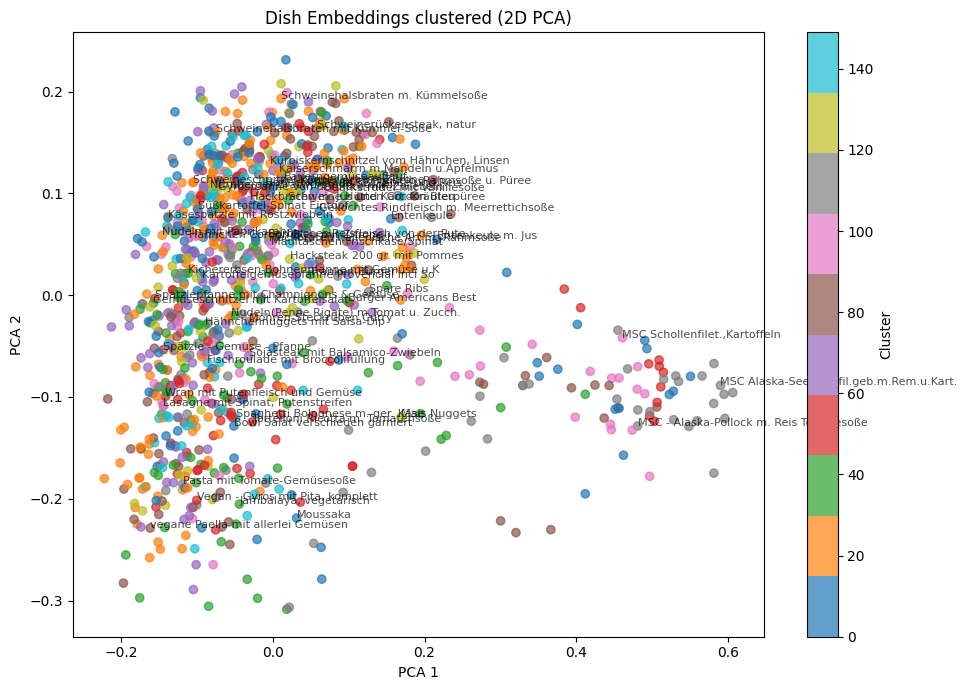

In [ ]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA


# Assume embedding_clustering_df has 'dish_name' and embedding columns (e.g., 0, 1, ..., n)
embedding_cols = [col for col in embedding_clustering_df.columns if col != 'dish_name']
X = embedding_clustering_df[embedding_cols].values

# Cluster the embeddings
n_clusters = 150
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
embedding_df['cluster'] = kmeans.fit_predict(X)

# Reduce to 2D for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.figure(figsize=(10, 7))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=embedding_df['cluster'], cmap='tab10', alpha=0.7)
plt.title('Dish Embeddings clustered (2D PCA)')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.colorbar(scatter, label='Cluster')
for i, name in enumerate(embedding_df['dish_name']):
    if i % 20 == 0:  # annotate every 20th for readability
        plt.annotate(name, (X_pca[i, 0], X_pca[i, 1]), fontsize=8, alpha=0.7)
plt.tight_layout()
plt.show()



In [ ]:
for cluster_id in range(n_clusters):
    cluster_members = embedding_df[embedding_df['cluster'] == cluster_id]['dish_name'].tolist()
    print(f"Cluster {cluster_id} ({len(cluster_members)} dishes):")
    for name in cluster_members:
        print(f"  - {name}")
    print()

Cluster 0 (4 dishes):
  - Moussaka "Griechische Art" , mit Räucher
  - Moussaka
  - Moussaka mit Soja
  - Arabisches Cous Cous m.Kicherer. u.Pfirs

Cluster 1 (1 dishes):
  - MSC - Wildlachs mit Gemüsestreifen

Cluster 2 (8 dishes):
  - Gemüse-Schaschlik Topf mit Süßkartoffel-
  - Süßkartoffel-Spinat Eintopf mit Vollkorn
  - Basis Bowl - zweierlei Linsen mit Süßkat
  - Süßkartoffel Topf
  - Fränkischer Kartoffel-Gemüsetopf
  - Süßkartoffel-Spinat Eintopf
  - Bowl Salat verschieden garniert
  - Indischer Rote Linsen Topf

Cluster 3 (10 dishes):
  - Käsespätzle mit Röstzwiebeln - frisch
  - Pfefferspießbraten
  - Pfeffergeschnetzeltes v.Schwein m.Nudeln
  - Pfeffersteak v.Schwein m. Püree
  - Käsespätzle mit Röstzwiebeln
  - Pfeffergeschnetzeltes v.Schwein m.Spätzl
  - Schweinegeschnetzeltes Züricher m. Spätz
  - Pfefferrahmgeschnetzeltes m. Spätzle
  - Schweinegeschnetzeltes m. Spätzle
  - Pfefferrahmgeschnetzeltes m.Nudeln

Cluster 4 (9 dishes):
  - MSC - Seelachsfilet "Samoa"
  - MSC -

### Elbow Method


inertia = []
cluster_range = range(2, 250) 

for k in cluster_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X)  # X_embeddings = PCA или оригинальные embedding
    inertia.append(kmeans.inertia_)

plt.plot(cluster_range, inertia, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.show()


### Silhouette Score


from sklearn.metrics import silhouette_score

silhouette_scores = []
for k in range(300, 500):
    kmeans = KMeans(n_clusters=k, random_state=42)
    cluster_labels = kmeans.fit_predict(X)
    score = silhouette_score(X, cluster_labels)
    silhouette_scores.append(score)

plt.plot(range(300, 500), silhouette_scores, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Analysis')
plt.show()


Random Forest for embedding (Task Type = CLUSTERING)

In [ ]:
df_essen_only_llm_clustering.head()


,date,original_name,target_amount,sold_amount,dish_name,weekday,year,dish_type,month,week,...,758,759,760,761,762,763,764,765,766,767
0,2014-01-07,Essen 3,190.0,185,Pasta mit Tomate-Gemüsesoße,1,2014,Essen (Menu),1,2,...,-0.004377,0.031876,-0.053406,0.047176,-0.015487,0.012520,-0.040504,0.027322,-0.013445,-0.008620
1,2014-01-07,Essen 2,240.0,237,Puten Cordon Bleu mit Zitrone,1,2014,Essen (Menu),1,2,...,0.020624,0.026666,-0.069059,0.030719,-0.028615,0.067060,-0.008744,0.013220,-0.048137,-0.024251
2,2014-01-07,Essen 1,162.0,159,Hacklett - Hacksteak,1,2014,Essen (Menu),1,2,...,0.016959,0.000032,-0.026228,-0.009184,0.046250,0.025233,0.014641,-0.033299,-0.029705,0.010379
3,2014-01-08,Essen 4,60.0,52,Nudelpfanne mit Muschelfleisch und Papri,2,2014,Essen (Menu),1,2,...,0.034301,0.030406,-0.045182,0.061938,-0.006775,0.000435,-0.013775,0.010836,-0.023485,0.041352
4,2014-01-08,Essen 5,270.0,265,Rösti Hauptgericht,2,2014,Essen (Menu),1,2,...,-0.015230,0.026844,-0.034156,0.018143,-0.011577,0.057255,-0.070778,-0.001394,-0.010010,0.019580


In [ ]:
embedding_df['cluster']

0       119
1        63
2        18
3        72
4       126
       ... 
1030     13
1031      3
1032     30
1033     28
1034      7
Name: cluster, Length: 1035, dtype: int32

In [ ]:
df_essen_only_llm_clustering['cluster'] = df_essen_only_llm_clustering['dish_name'].map(embedding_df.set_index('dish_name')['cluster'])

In [ ]:
df_essen_no_covid_cluster = df_essen_no_covid.copy()

In [ ]:
df_essen_no_covid_cluster['cluster'] = df_essen_no_covid_cluster['dish_name'].map(embedding_df.set_index('dish_name')['cluster'])

In [ ]:
df_essen_no_covid_cluster.head()

,date,original_name,target_amount,sold_amount,dish_name,weekday,year,dish_type,month,week,...,rolling_30d_sold_mean,rolling_30d_sold_median,rolling_30d_target_mean,rolling_30d_target_median,daily_total_sales,rolling_7d_total_sales,rolling_30d_total_sales,dish_freq,is_essen,cluster
5,2014-01-07,Essen 3,190.0,185,Pasta mit Tomate-Gemüsesoße,1,2014,Essen (Menu),1,2,...,66.668705,62.374719,69.736775,65.690484,861,861.000000,861.000000,419,1,119
6,2014-01-07,Essen 2,240.0,237,Puten Cordon Bleu mit Zitrone,1,2014,Essen (Menu),1,2,...,66.668705,62.374719,69.736775,65.690484,861,861.000000,861.000000,1304,1,63
7,2014-01-07,Essen 1,162.0,159,Hacklett - Hacksteak,1,2014,Essen (Menu),1,2,...,66.668705,62.374719,69.736775,65.690484,861,861.000000,861.000000,1812,1,18
13,2014-01-08,Essen 4,60.0,52,Nudelpfanne mit Muschelfleisch und Papri,2,2014,Essen (Menu),1,2,...,66.668705,62.374719,69.736775,65.690484,676,728.857143,789.846154,1523,1,72
14,2014-01-08,Essen 5,270.0,265,Rösti Hauptgericht,2,2014,Essen (Menu),1,2,...,66.668705,62.374719,69.736775,65.690484,676,702.428571,781.714286,666,1,126


In [ ]:
y = df_essen_no_covid_cluster['sold_amount']

# Features
base_features = [
    'year', 'weekday', 'month', 'day', 'is_weekend', 'weekofyear',
     'rolling_7d_sold_mean', 'rolling_7d_sold_median',    
    'rolling_30d_sold_mean', 'rolling_30d_sold_median',
    'rolling_7d_total_sales', 'rolling_30d_total_sales', 'cluster'
]

X = df_essen_no_covid_cluster[base_features]

df_essen_no_covid_cluster = df_essen_no_covid_cluster.sort_values('date')
split_index = int(len(df_essen_no_covid_cluster) * 0.8)

X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

MAE_RF = mean_absolute_error(y_test, y_pred)
R2_RF = r2_score(y_test, y_pred)

print("Random Forest evaluation:")
print("MAE:", mean_absolute_error(y_test, y_pred))
print("R²:", r2_score(y_test, y_pred))

Random Forest evaluation:
MAE: 34.419962264150946
R²: 0.6149525798324117


In [ ]:
essen_nc_pca_cluster['cluster'] = essen_nc_pca_cluster['dish_name'].map(embedding_df.set_index('dish_name')['cluster'])

In [ ]:
y = essen_nc_pca_cluster['sold_amount']

# Features
base_features = [
    'year', 'weekday', 'month', 'day', 'is_weekend', 'weekofyear',
     'rolling_7d_sold_mean', 'rolling_7d_sold_median',    
    'rolling_30d_sold_mean', 'rolling_30d_sold_median',
    'rolling_7d_total_sales', 'rolling_30d_total_sales', 'cluster'
]

X = essen_nc_pca_cluster[base_features + pca_features]

essen_nc_pca_cluster = essen_nc_pca_cluster.sort_values('date')
split_index = int(len(essen_nc_pca_cluster) * 0.8)

X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

MAE_RF = mean_absolute_error(y_test, y_pred)
R2_RF = r2_score(y_test, y_pred)

print("Random Forest evaluation:")
print("MAE:", mean_absolute_error(y_test, y_pred))
print("R²:", r2_score(y_test, y_pred))

Random Forest evaluation:
MAE: 32.85284905660377
R²: 0.6488287081253544


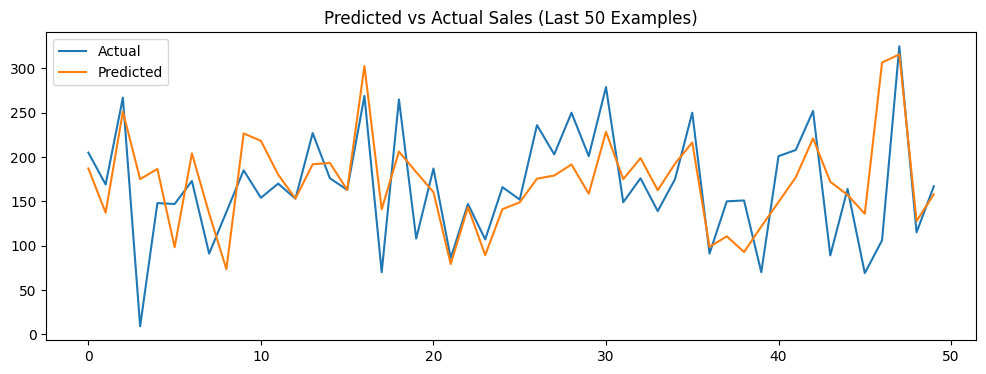

In [ ]:
plt.figure(figsize=(12, 4))
plt.plot(y_test.values[-50:], label='Actual')
plt.plot(y_pred[-50:], label='Predicted')
plt.legend()
plt.title('Predicted vs Actual Sales (Last 50 Examples)')
plt.show()

### XGBoost model

In [ ]:


model_xgb = xgb.XGBRegressor(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model_xgb.fit(X_train, y_train)
y_pred_xgb = model_xgb.predict(X_test)

In [ ]:
mae = mean_absolute_error(y_test, y_pred_xgb)
r2 = r2_score(y_test, y_pred_xgb)

print(f"XGBoost MAE: {mae:.2f}")
print(f"XGBoost R²: {r2:.2f}")


XGBoost MAE: 33.22
XGBoost R²: 0.65
